In [1]:
import pandas as pd
df = pd.read_csv('./data/cytof.csv', index_col=0)

In [2]:
df_ts = df[(df.observableId == 'p.ERK') & (df.simulationConditionId.str.endswith('__EGF'))].pivot_table(index='preequilibrationConditionId', columns='time', values='measurement')

In [3]:
df_ts

time,0.0,5.5,7.0,9.0,12.0,13.0,14.0,17.0,23.0,30.0,35.0,40.0,60.0
preequilibrationConditionId,,,,,,,,,,,,,
c184A1,2.610448,3.562203,3.503852,3.677882,NaN,3.522100,NaN,3.333949,3.631606,3.225276,NaN,2.997180,2.794183
c184B5,2.303940,3.657244,3.324000,3.025286,NaN,3.918409,NaN,3.321868,3.713584,2.687524,NaN,2.625606,2.612064
cBT20,3.805443,3.990476,4.411401,4.240665,NaN,3.993469,NaN,4.529850,3.900909,4.510031,NaN,3.737119,4.148405
cBT474,3.089931,3.320202,3.088775,3.261580,NaN,3.459100,NaN,3.215458,2.978081,3.171048,NaN,2.903087,3.052457
cBT483,2.941606,3.898188,3.991941,3.743703,NaN,3.468802,NaN,3.100587,3.201544,2.630544,NaN,2.680406,2.462154
cBT549,2.774730,3.805003,3.986812,3.723047,NaN,3.315204,NaN,3.625836,3.330300,3.653468,NaN,3.253072,3.417519
cCAL148,1.969755,3.532953,3.275293,3.478243,NaN,3.335307,NaN,3.302267,3.362060,3.269086,NaN,2.330384,2.884917
cCAL51,2.625466,4.037332,3.771651,3.893120,NaN,3.844919,NaN,3.386502,3.715885,3.631095,NaN,3.872647,3.624477
cCAL851,3.290168,3.821046,3.551637,3.818823,NaN,3.651139,NaN,3.306332,3.510824,3.157344,NaN,3.232957,2.764083


In [4]:
amplitude = (df_ts.max(axis=1) - df_ts[0.0]).rename('amplitude')

In [5]:
dropoff = (df_ts.max(axis=1) - df_ts[60.0]).rename('dropoff')

In [6]:
max = (df_ts.max(axis=1)).rename('max')

<Axes: >

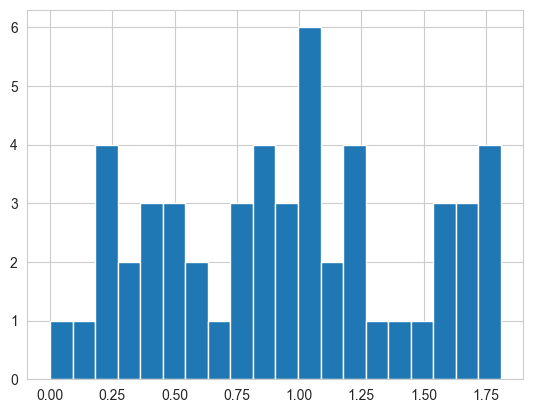

In [7]:
amplitude.hist(bins=20)

<Axes: >

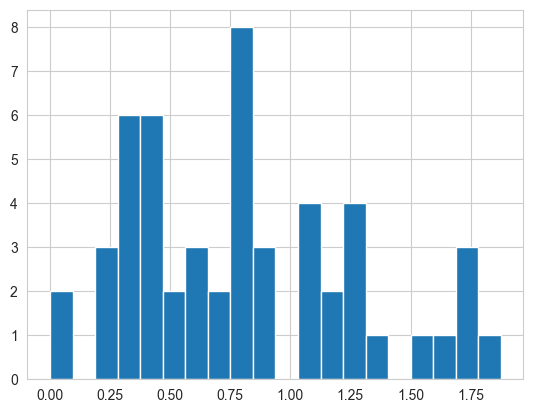

In [8]:
dropoff.hist(bins=20)

<Axes: xlabel='max', ylabel='dropoff'>

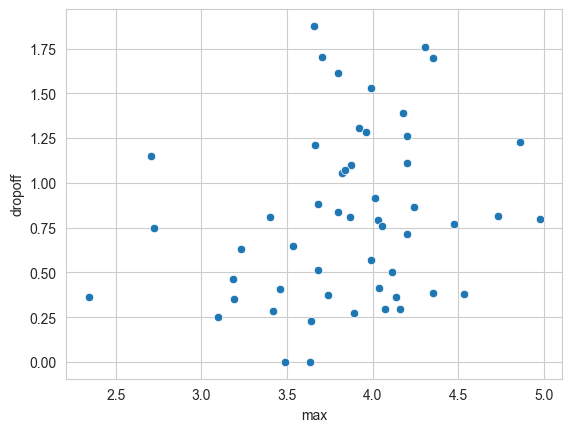

In [10]:
import seaborn as sns
sns.scatterplot(pd.concat([dropoff, amplitude, max], axis=1), x='max', y='dropoff')

In [11]:
import numpy as np
from dataclasses import dataclass
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def _sigmoid(x, center, width):
    # width > 0 makes the transition slope ~1/width; allow negative for decreasing steps
    return 1.0 / (1.0 + np.exp(-(x - center) / width))

def double_sigmoid_product(x, A, B, c1, w1, C, c2, w2):
    """
    Model: y = B + A * sigmoid((x-c1)/w1) * sigmoid((x-c2)/w2)
      A: amplitude (scale of the product)
      B: baseline (offset)
      c1, c2: centers of the two sigmoids
      w1, w2: widths (slope controls; can be negative for decreasing steps)
    """
    return A + B * _sigmoid(x, c1, np.power(10,w1)) - (C)* np.heaviside(x-c2,0.0) * (1-np.exp(-np.power(10,w2)*(x-c2)))

@dataclass
class FitResult:
    params: dict
    popt: np.ndarray
    pcov: np.ndarray
    stderr: np.ndarray
    params_stderr: dict
    p0: dict


def fit_double_sigmoid(x, y, max_nfev=20000, plot=False):
    """
    Fit y ~ B + A * s1 * s2 with scipy.optimize.curve_fit.

    Parameters
    ----------
    x, y : 1D arrays
    max_nfev : max function evaluations

    Returns
    -------
    FitResult with dict of params, covariance, and standard errors.
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    param_names = ['A', 'B', 'c1', 'w1', 'C', 'c2', 'w2']

    # Default initial guesses
    A0 = y[0]
    B0 = y.max() - A0
    c10 = 2
    w10 = -0.5
    C0 = y.max() - y[-1]
    c20 = 10
    w20 = -1.5
    p0 =    [ A0,     B0,     c10, w10,    C0,  c20,  w20]

    lower = [ A0-0.2, B0-0.5,   1,  -1,    C0-0.5,   5,   -3]
    upper = [ A0+0.2, B0+0.5,   10,   1,    C0+0.5,   50,  0]
    bounds = (lower, upper)

    def _fit(weights=None):
        sigma = None
        if weights is not None:
            # curve_fit uses sigma as std; supply std = 1/sqrt(weight)
            sigma = 1.0 / np.sqrt(np.clip(weights, 1e-12, np.inf))

        popt, pcov = curve_fit(
            double_sigmoid_product,
            x,
            y,
            p0=p0,
            sigma=sigma,
            absolute_sigma=(sigma is not None),
            bounds=bounds,
            max_nfev=max_nfev,
        )
        return popt, pcov

    # Stage 1: standard (or weighted) LS
    popt, pcov = _fit()

    # Compute residuals, build Huber weights, refit
    yhat = double_sigmoid_product(x, *popt)
    resid = y - yhat
    # Huber scale via MAD
    mad = np.median(np.abs(resid - np.median(resid))) + 1e-12
    c = 1.345  # Huber tuning
    r = resid / (1.4826 * mad)
    w = np.where(np.abs(r) <= c, 1.0, (c / np.abs(r)) )
    # popt, pcov = _fit(weights=w)

    # Standard errors from covariance
    stderr = np.sqrt(np.maximum(np.diag(pcov), 0.0))

    params = dict(zip(param_names, popt))
    params_stderr = dict(zip(param_names, stderr))
    params_0 = dict(zip(param_names, p0))
    if plot:
        plt.figure()
        plt.scatter(x, y, label='data')
        x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        y_fit = double_sigmoid_product(x_fit, *popt)
        y0 = double_sigmoid_product(x_fit, *p0)
        plt.plot(x_fit, y_fit, 'r-', label='fit')
        plt.plot(x_fit, y0, 'b-', label='init')
        plt.legend()
        plt.show()
    return FitResult(params=params, popt=popt, pcov=pcov, stderr=stderr, params_stderr=params_stderr, p0=params_0)

Fitting row 0 (c184A1)


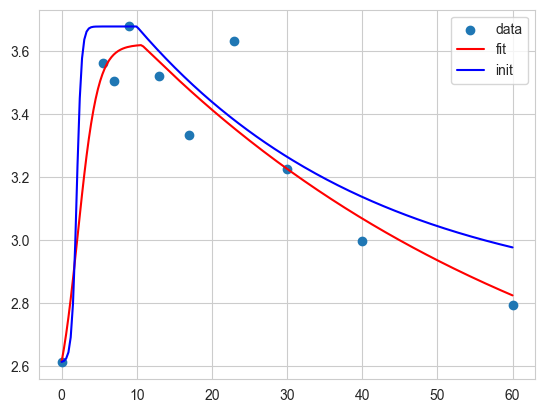

{'A': np.float64(2.410448191967558), 'B': np.float64(1.210342845222183), 'c1': np.float64(2.137301573049597), 'w1': np.float64(0.12466795526593849), 'C': np.float64(1.3836991242530357), 'c2': np.float64(10.670195750207998), 'w2': np.float64(-1.7594443889214018)}
Fitting row 1 (c184B5)


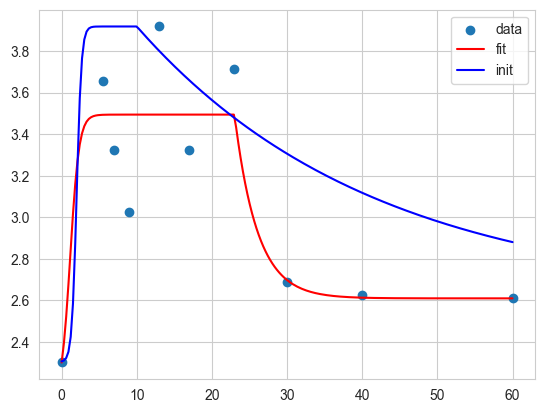

{'A': np.float64(2.1261701006040696), 'B': np.float64(1.3682116498902177), 'c1': np.float64(1.1384158619617788), 'w1': np.float64(-0.22620965709365137), 'C': np.float64(0.8842206461385621), 'c2': np.float64(23.000001143297364), 'w2': np.float64(-0.4818406418595524)}
Fitting row 2 (cBT20)


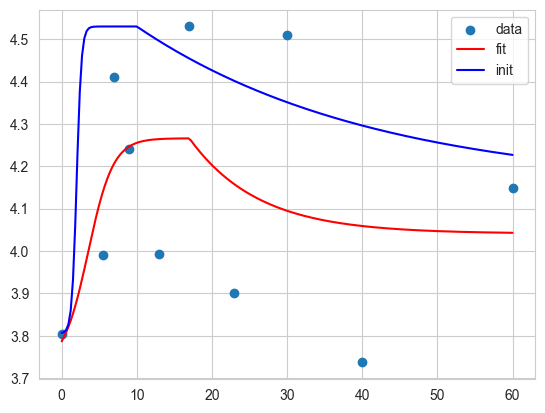

{'A': np.float64(3.7297852018555107), 'B': np.float64(0.5362164142479154), 'c1': np.float64(3.5290819702554206), 'w1': np.float64(0.2205676235534557), 'C': np.float64(0.22493364779672262), 'c2': np.float64(17.00000068910611), 'w2': np.float64(-0.9591363737600306)}
Fitting row 3 (cBT474)


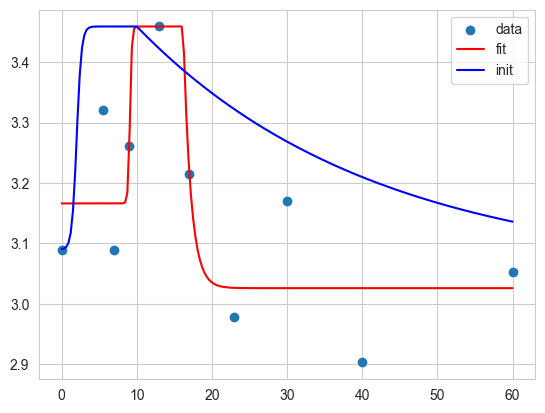

{'A': np.float64(3.1663029056254706), 'B': np.float64(0.2927970953040286), 'c1': np.float64(9.091125837281801), 'w1': np.float64(-0.9031076308007372), 'C': np.float64(0.4330192339880201), 'c2': np.float64(16.17232765157976), 'w2': np.float64(-2.0782651706023112e-80)}
Fitting row 4 (cBT483)


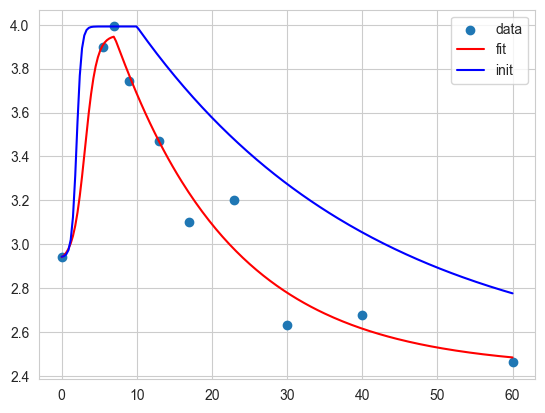

{'A': np.float64(2.9233535511422626), 'B': np.float64(1.0293168821332161), 'c1': np.float64(3.1101222479477673), 'w1': np.float64(-0.11195363772975203), 'C': np.float64(1.517377630490891), 'c2': np.float64(6.999999749691099), 'w2': np.float64(-1.1907536703790467)}
Fitting row 5 (cBT549)


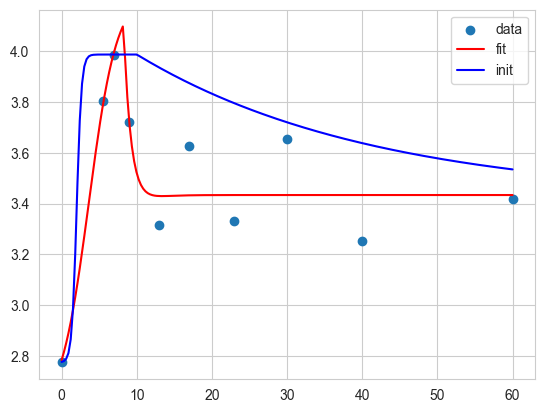

{'A': np.float64(2.5747296211045962), 'B': np.float64(1.657911350435971), 'c1': np.float64(3.615149932623669), 'w1': np.float64(0.2719564236830631), 'C': np.float64(0.7988606753920243), 'c2': np.float64(8.24493995616021), 'w2': np.float64(-4.5120013312581183e-32)}
Fitting row 6 (cCAL148)


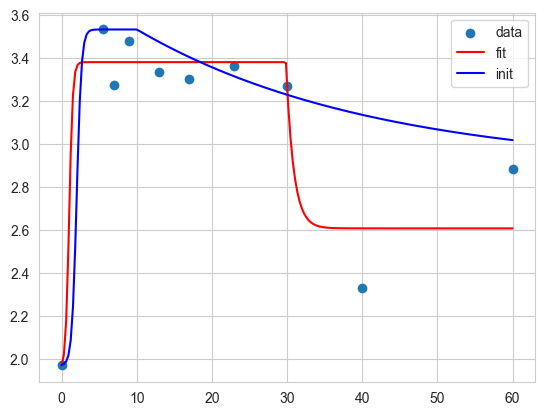

{'A': np.float64(1.9483257049145979), 'B': np.float64(1.4326948693696242), 'c1': np.float64(1.000007632057785), 'w1': np.float64(-0.621793182472902), 'C': np.float64(0.7733787403623136), 'c2': np.float64(29.843637215519372), 'w2': np.float64(-1.6449625860258388e-15)}
Fitting row 7 (cCAL51)


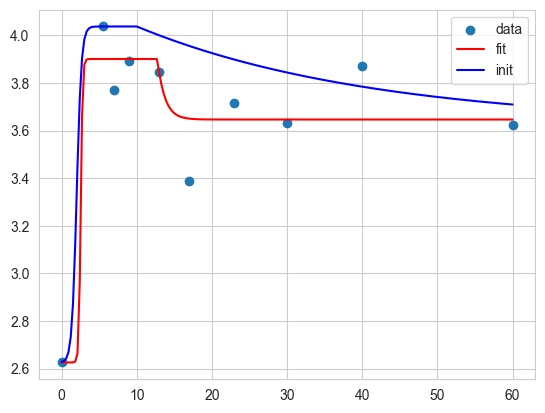

{'A': np.float64(2.6254664770890366), 'B': np.float64(1.2752345908884715), 'c1': np.float64(2.5352450474682167), 'w1': np.float64(-0.9133865338041196), 'C': np.float64(0.25432680891483894), 'c2': np.float64(12.727811412529947), 'w2': np.float64(-1.381235330015772e-12)}
Fitting row 8 (cCAL851)


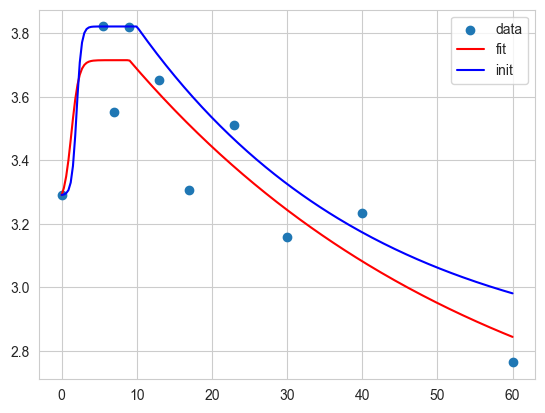

{'A': np.float64(3.258203042347285), 'B': np.float64(0.45680135668624), 'c1': np.float64(1.3049256073998363), 'w1': np.float64(-0.29615280054970705), 'C': np.float64(1.3318534201320251), 'c2': np.float64(9.000000735963127), 'w2': np.float64(-1.6822436926200637)}
Fitting row 9 (cDU4475)


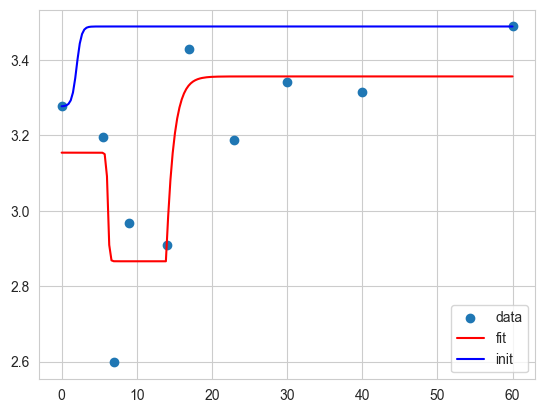

{'A': np.float64(3.1540443307291155), 'B': np.float64(-0.28802761986249464), 'c1': np.float64(6.158320265757047), 'w1': np.float64(-0.9999901432317623), 'C': np.float64(-0.49018304234234095), 'c2': np.float64(13.895112965713311), 'w2': np.float64(-2.6570693455861013e-83)}
Fitting row 10 (cEFM192A)


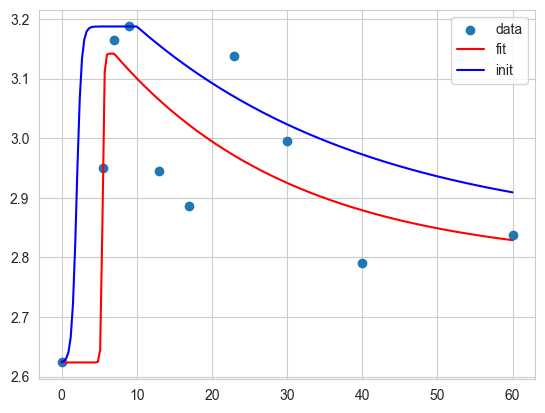

{'A': np.float64(2.6235298134140512), 'B': np.float64(0.5182372599984888), 'c1': np.float64(5.446543824029695), 'w1': np.float64(-0.9914474595444493), 'C': np.float64(0.35143258878321787), 'c2': np.float64(6.988654691276244), 'w2': np.float64(-1.3793024631167503)}
Fitting row 11 (cEVSAT)


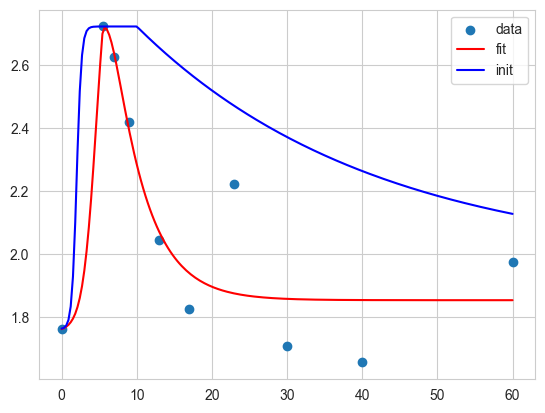

{'A': np.float64(1.754002902517902), 'B': np.float64(1.329977072102652), 'c1': np.float64(4.618486231816228), 'w1': np.float64(-0.043717079832517644), 'C': np.float64(1.2302915265306649), 'c2': np.float64(5.50001726237448), 'w2': np.float64(-0.6348003080650004)}
Fitting row 12 (cHBL100)


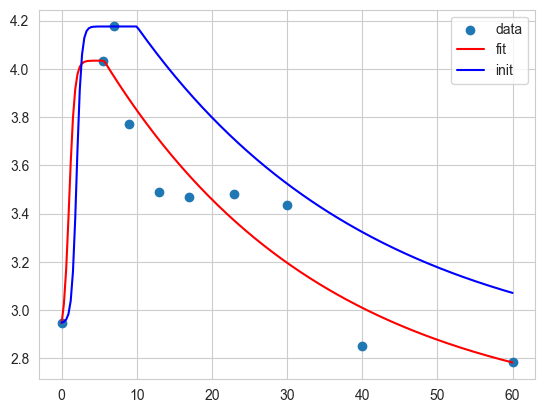

{'A': np.float64(2.8720873843488475), 'B': np.float64(1.1619974221437657), 'c1': np.float64(1.0000243135276234), 'w1': np.float64(-0.42981828307224473), 'C': np.float64(1.482148520999545), 'c2': np.float64(5.636090114642125), 'w2': np.float64(-1.4657873795815048)}
Fitting row 13 (cHCC1187)


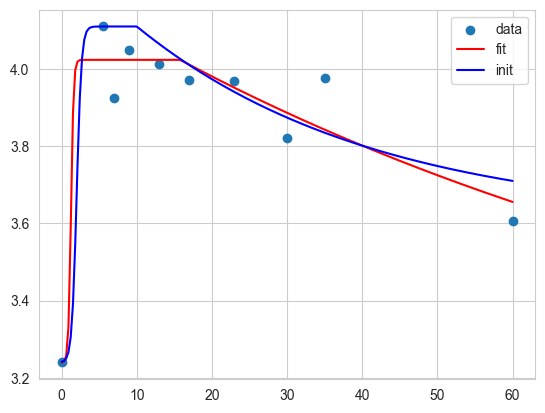

{'A': np.float64(3.2394178397900575), 'B': np.float64(0.7834251532899752), 'c1': np.float64(1.244935034459165), 'w1': np.float64(-0.7742085071162712), 'C': np.float64(1.0030073089712068), 'c2': np.float64(15.758061819684466), 'w2': np.float64(-1.9864649459645312)}
Fitting row 14 (cHCC1395)


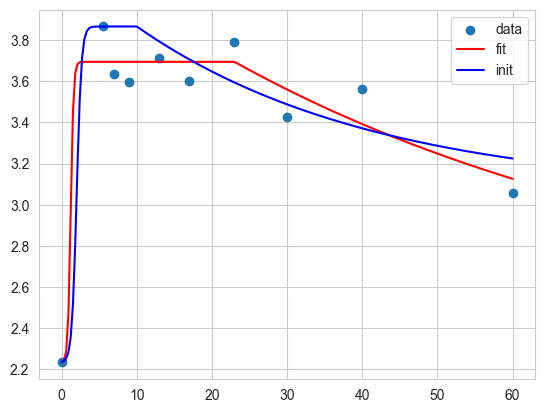

{'A': np.float64(2.2313500848506935), 'B': np.float64(1.4632057529051121), 'c1': np.float64(1.2067510535422379), 'w1': np.float64(-0.7310525468259487), 'C': np.float64(1.2807633873710669), 'c2': np.float64(23.00000003776038), 'w2': np.float64(-1.799883420283495)}
Fitting row 15 (cHCC1419)


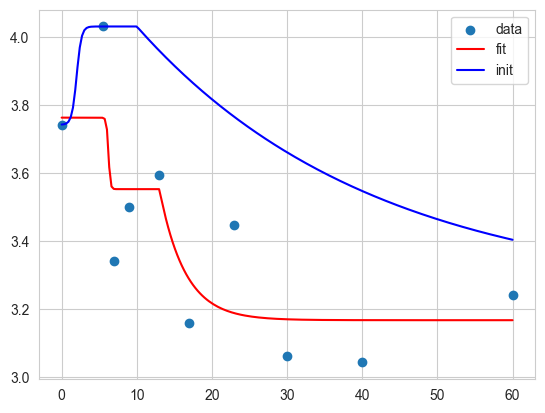

{'A': np.float64(3.763177016527944), 'B': np.float64(-0.2106460579167856), 'c1': np.float64(6.230620188902233), 'w1': np.float64(-0.9059571741154575), 'C': np.float64(0.38599768364428594), 'c2': np.float64(12.999999974066533), 'w2': np.float64(-0.5333437447596354)}
Fitting row 16 (cHCC1428)


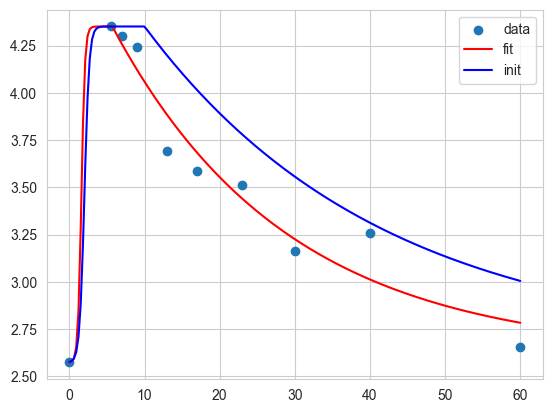

{'A': np.float64(2.5714196667524347), 'B': np.float64(1.7795991197684708), 'c1': np.float64(1.6000142497462733), 'w1': np.float64(-0.6372040736112828), 'C': np.float64(1.7352395452630198), 'c2': np.float64(5.709806264508818), 'w2': np.float64(-1.3659380935472354)}
Fitting row 17 (cHCC1500)


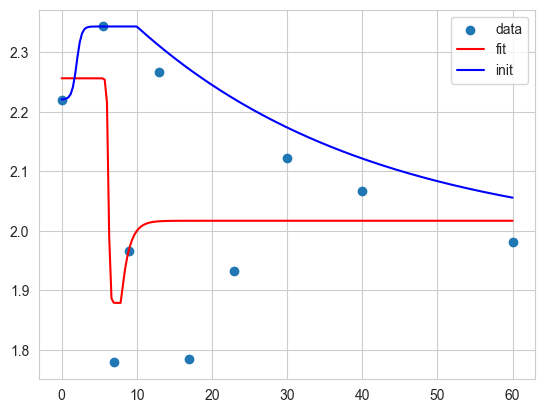

{'A': np.float64(2.2563125314425947), 'B': np.float64(-0.37731748633210577), 'c1': np.float64(6.242409774447082), 'w1': np.float64(-0.9999805930596272), 'C': np.float64(-0.1380027506792014), 'c2': np.float64(7.9093052845304594), 'w2': np.float64(-1.9445902712563872e-09)}
Fitting row 18 (cHCC1569)


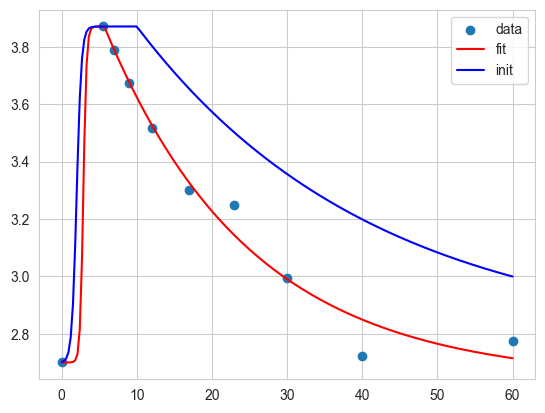

{'A': np.float64(2.699711608743993), 'B': np.float64(1.1714214165208816), 'c1': np.float64(2.8808853753296524), 'w1': np.float64(-0.6736219347098009), 'C': np.float64(1.230683046629512), 'c2': np.float64(5.670311544341911), 'w2': np.float64(-1.286602570306333)}
Fitting row 19 (cHCC1806)


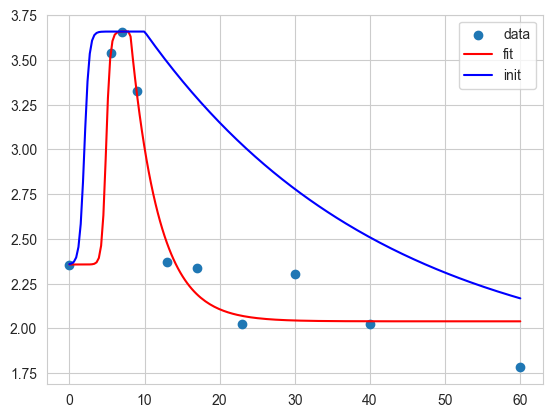

{'A': np.float64(2.3570957175935234), 'B': np.float64(1.301588173874886), 'c1': np.float64(4.878876498375908), 'w1': np.float64(-0.5680464403061105), 'C': np.float64(1.6189399392626085), 'c2': np.float64(8.075545494759929), 'w2': np.float64(-0.5740092210789132)}
Fitting row 20 (cHCC1937)


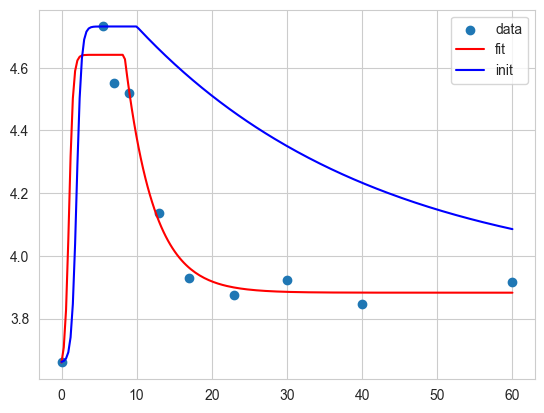

{'A': np.float64(3.633572267998781), 'B': np.float64(1.0076339693431882), 'c1': np.float64(1.000031433156517), 'w1': np.float64(-0.5574633545371683), 'C': np.float64(0.7585151157232187), 'c2': np.float64(8.37085090165181), 'w2': np.float64(-0.5815386017491052)}
Fitting row 21 (cHCC1954)


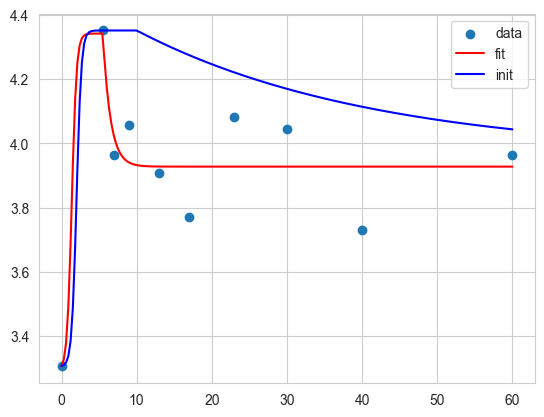

{'A': np.float64(3.292637905257175), 'B': np.float64(1.0491645953548006), 'c1': np.float64(1.3643425899058843), 'w1': np.float64(-0.5011473228908218), 'C': np.float64(0.4139811304946182), 'c2': np.float64(5.499999866431898), 'w2': np.float64(-0.0016745954675496044)}
Fitting row 22 (cHCC202)


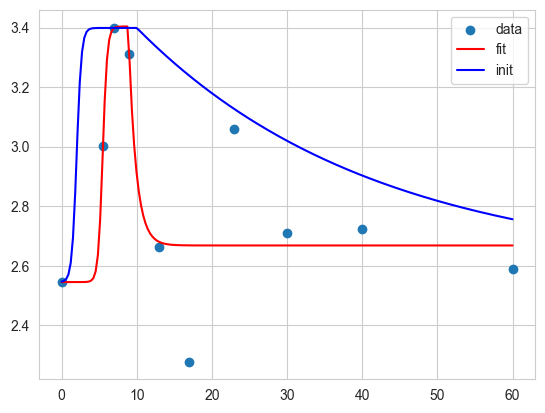

{'A': np.float64(2.545349986527994), 'B': np.float64(0.8581304379294824), 'c1': np.float64(5.46126831779048), 'w1': np.float64(-0.5246424221312443), 'C': np.float64(0.7351375542319231), 'c2': np.float64(8.867453438859862), 'w2': np.float64(-2.1023828728729998e-12)}
Fitting row 23 (cHCC2185)


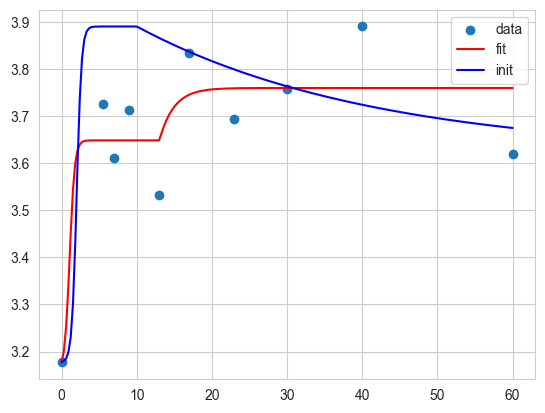

{'A': np.float64(3.1580970979457668), 'B': np.float64(0.4910397584554003), 'c1': np.float64(1.0747359650818418), 'w1': np.float64(-0.4787801041403049), 'C': np.float64(-0.11142573576034386), 'c2': np.float64(13.000000892302857), 'w2': np.float64(-0.2878901159860561)}
Fitting row 24 (cHCC3153)


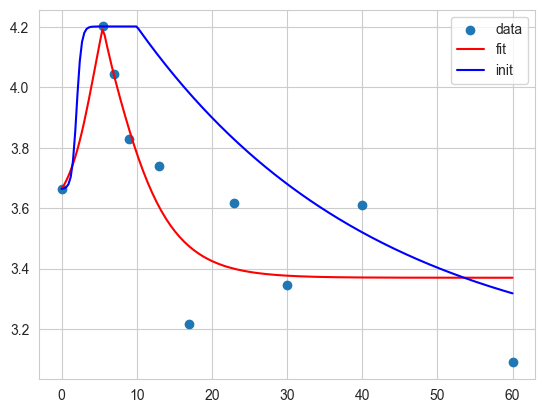

{'A': np.float64(3.5863538191552355), 'B': np.float64(0.9536045056087644), 'c1': np.float64(4.421963208221975), 'w1': np.float64(0.25979872460653486), 'C': np.float64(1.170292710543772), 'c2': np.float64(5.500027531990785), 'w2': np.float64(-0.6771514583370416)}
Fitting row 25 (cHCC38)


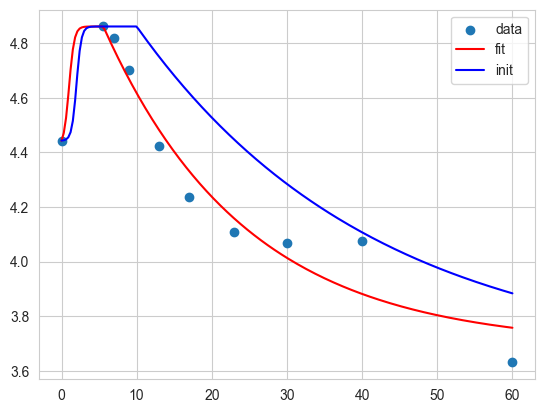

{'A': np.float64(4.41843965222825), 'B': np.float64(0.44217724498437033), 'c1': np.float64(1.0000305359880013), 'w1': np.float64(-0.4565280328512209), 'C': np.float64(1.1686336983550563), 'c2': np.float64(5.562214203918065), 'w2': np.float64(-1.2774877914484066)}
Fitting row 26 (cHCC70)


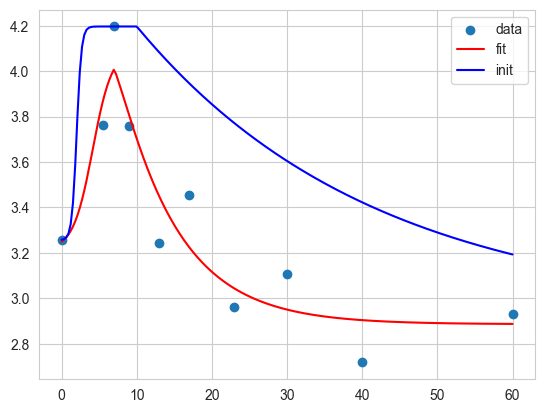

{'A': np.float64(3.2150824618640397), 'B': np.float64(0.8805590272298), 'c1': np.float64(4.134626911998753), 'w1': np.float64(0.10880340697547822), 'C': np.float64(1.2098870786143054), 'c2': np.float64(7.0000002849325), 'w2': np.float64(-0.8944608194224634)}
Fitting row 27 (cHDQP1)


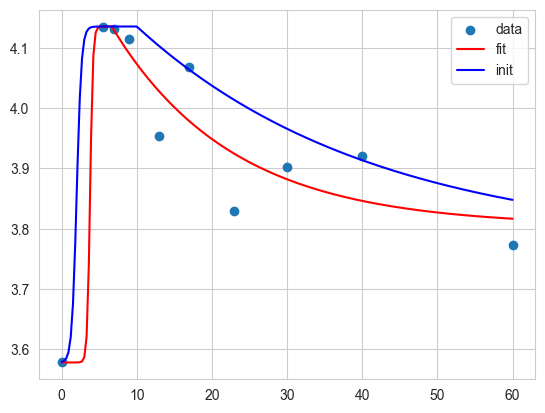

{'A': np.float64(3.578152519901013), 'B': np.float64(0.5574821605996745), 'c1': np.float64(3.7834036711768153), 'w1': np.float64(-0.7298996710297556), 'C': np.float64(0.33093508723754905), 'c2': np.float64(6.646603427308772), 'w2': np.float64(-1.2059954244902509)}
Fitting row 28 (cHs578T)


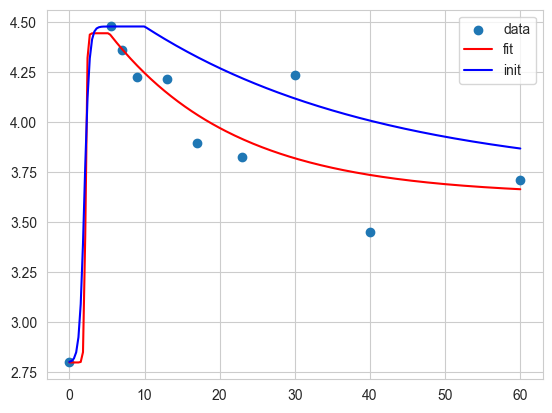

{'A': np.float64(2.796479534042545), 'B': np.float64(1.6461579021704391), 'c1': np.float64(2.1571022664557113), 'w1': np.float64(-0.993696916502726), 'C': np.float64(0.8109895264937769), 'c2': np.float64(5.284004230137319), 'w2': np.float64(-1.2248033458546235)}
Fitting row 29 (cJIMT1)


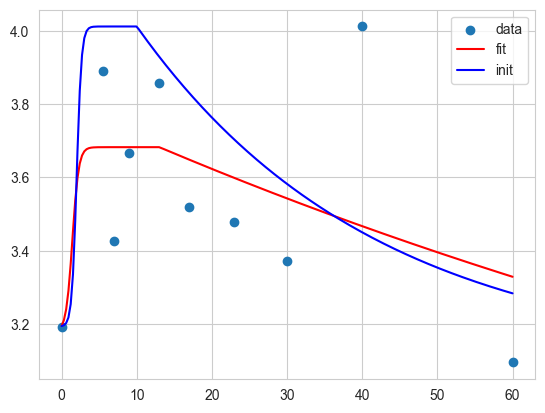

{'A': np.float64(3.1785476970507487), 'B': np.float64(0.5039152464299573), 'c1': np.float64(1.4313770645697521), 'w1': np.float64(-0.37642918565400973), 'C': np.float64(1.4000089044710924), 'c2': np.float64(13.000000256464272), 'w2': np.float64(-2.2080090861214074)}
Fitting row 30 (cMCF10A)


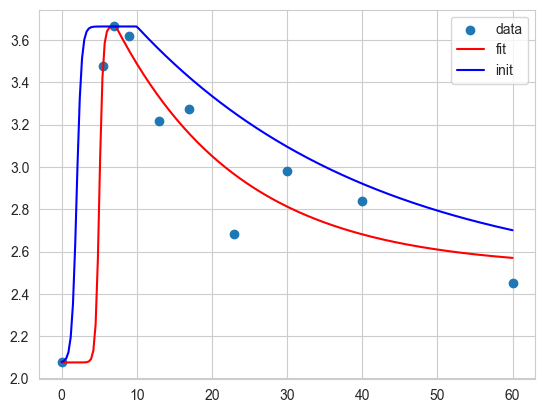

{'A': np.float64(2.0756084292149395), 'B': np.float64(1.5887521171826482), 'c1': np.float64(5.017072006264096), 'w1': np.float64(-0.6181484604513378), 'C': np.float64(1.1422518738031455), 'c2': np.float64(7.213360562253206), 'w2': np.float64(-1.2211594577874803)}
Fitting row 31 (cMCF12A)


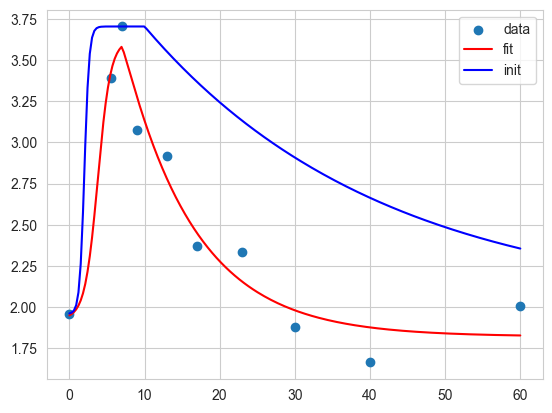

{'A': np.float64(1.9282401064508001), 'B': np.float64(1.6944457765237002), 'c1': np.float64(3.775854354353159), 'w1': np.float64(-0.06803401208218096), 'C': np.float64(1.8029406125541179), 'c2': np.float64(6.999999847079901), 'w2': np.float64(-0.9771967187664088)}
Fitting row 32 (cMCF7)


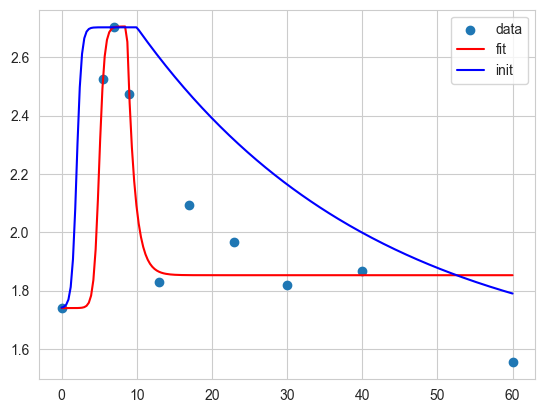

{'A': np.float64(1.7401484842001678), 'B': np.float64(0.9653693700423019), 'c1': np.float64(4.987826941655532), 'w1': np.float64(-0.45883874806056646), 'C': np.float64(0.8526303839564429), 'c2': np.float64(8.679856747575004), 'w2': np.float64(-8.016274905038687e-14)}
Fitting row 33 (cMDAMB134VI)


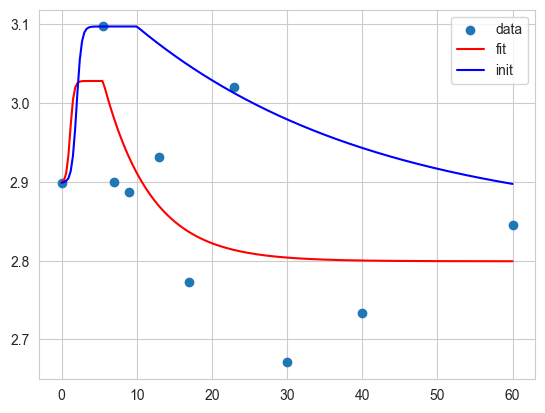

{'A': np.float64(2.897513362087965), 'B': np.float64(0.1307349955414101), 'c1': np.float64(1.1364693528200367), 'w1': np.float64(-0.6068369791310124), 'C': np.float64(0.2289974273622814), 'c2': np.float64(5.499999921493878), 'w2': np.float64(-0.7993645503424361)}
Fitting row 34 (cMDAMB157)


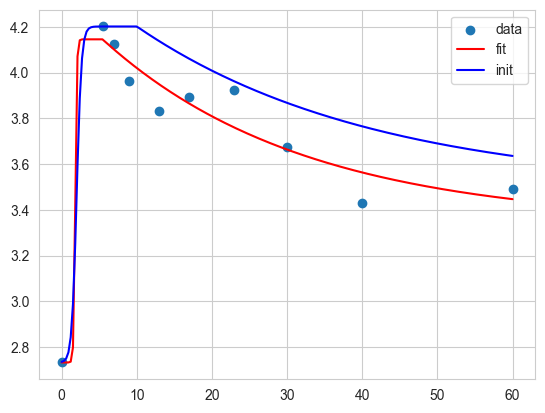

{'A': np.float64(2.732743829661351), 'B': np.float64(1.4125826504764094), 'c1': np.float64(1.8156319143718114), 'w1': np.float64(-0.9912588107480088), 'C': np.float64(0.8040598253079022), 'c2': np.float64(5.4466299505337945), 'w2': np.float64(-1.4289798969755572)}
Fitting row 35 (cMDAMB175VII)


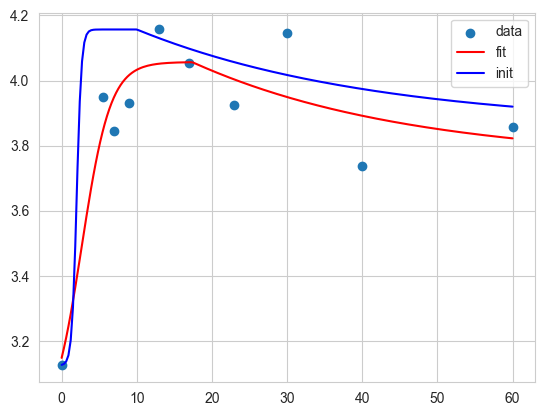

{'A': np.float64(2.925504221017366), 'B': np.float64(1.1314317078200313), 'c1': np.float64(2.6755650170178993), 'w1': np.float64(0.28052025376566325), 'C': np.float64(0.30366007389378763), 'c2': np.float64(17.386853634296727), 'w2': np.float64(-1.4604969269209942)}
Fitting row 36 (cMDAMB231)


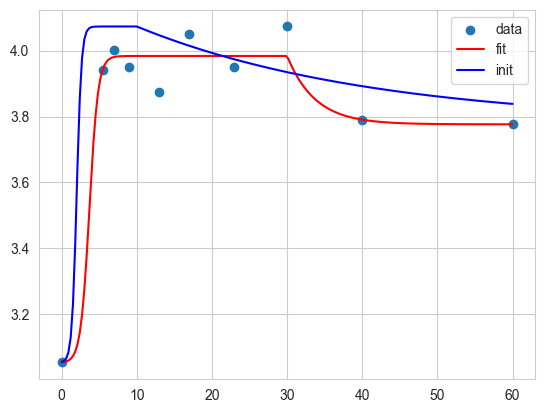

{'A': np.float64(3.052709992699398), 'B': np.float64(0.9309935273565659), 'c1': np.float64(3.6893561019521552), 'w1': np.float64(-0.23821186582295617), 'C': np.float64(0.20733541076088444), 'c2': np.float64(30.00000007499956), 'w2': np.float64(-0.5711220095109137)}
Fitting row 37 (cMDAMB361)


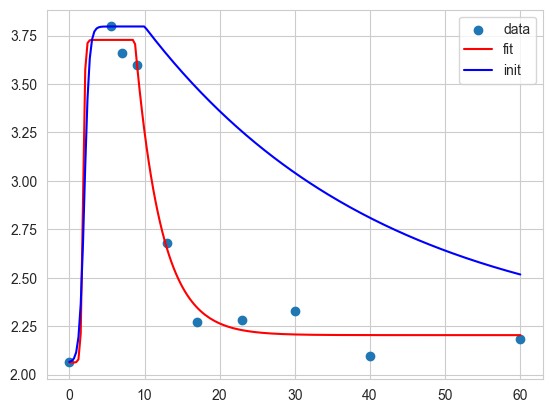

{'A': np.float64(2.0628456923982768), 'B': np.float64(1.6650319498698911), 'c1': np.float64(1.8107924673807552), 'w1': np.float64(-0.8843829313394186), 'C': np.float64(1.5238904599118388), 'c2': np.float64(8.693099901224457), 'w2': np.float64(-0.5438768738507768)}
Fitting row 38 (cMDAMB415)


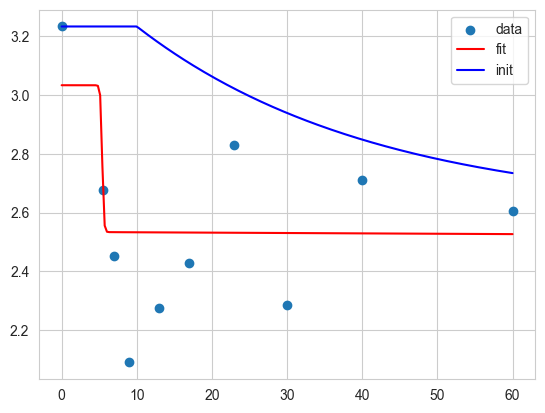

{'A': np.float64(3.0335045469951036), 'B': np.float64(-0.49999999999999994), 'c1': np.float64(5.40325034247272), 'w1': np.float64(-0.974961150152), 'C': np.float64(0.12845068491724868), 'c2': np.float64(5.000000000000001), 'w2': np.float64(-2.9999999999999996)}
Fitting row 39 (cMDAMB453)


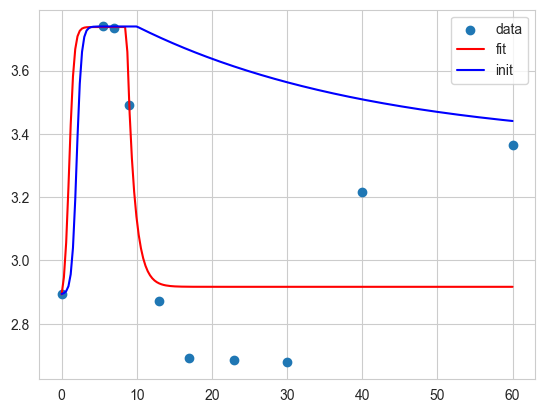

{'A': np.float64(2.852349666465624), 'B': np.float64(0.8852323357138565), 'c1': np.float64(1.0001438552641075), 'w1': np.float64(-0.48234628124927115), 'C': np.float64(0.8207946345679025), 'c2': np.float64(8.64307677528334), 'w2': np.float64(-5.065514280240645e-07)}
Fitting row 40 (cMDAMB468)


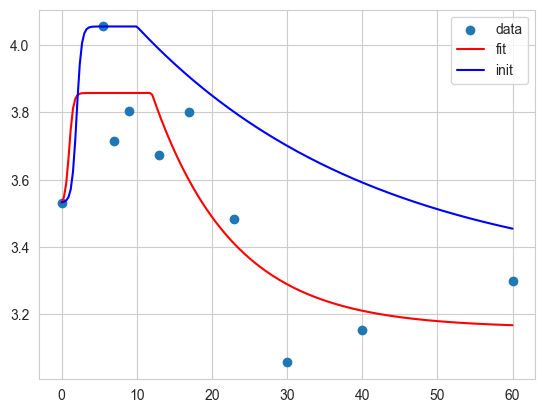

{'A': np.float64(3.5229586882256996), 'B': np.float64(0.33504495207310325), 'c1': np.float64(1.0003495574034533), 'w1': np.float64(-0.5535078676952908), 'C': np.float64(0.6981467287257124), 'c2': np.float64(11.975032230150207), 'w2': np.float64(-1.029541906930482)}
Fitting row 41 (cMFM223)


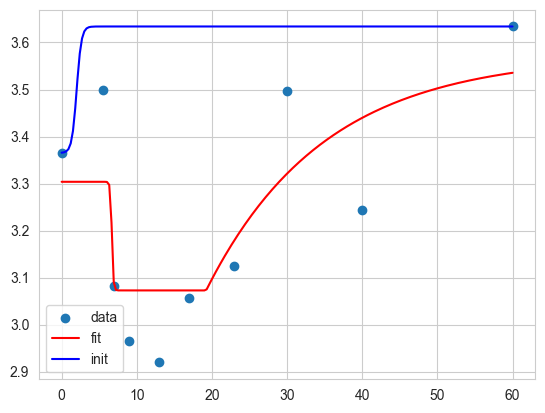

{'A': np.float64(3.3036872892212568), 'B': np.float64(-0.23105756013396792), 'c1': np.float64(6.684715206235354), 'w1': np.float64(-0.9999999571059904), 'C': np.float64(-0.49999999999999994), 'c2': np.float64(19.226400769995813), 'w2': np.float64(-1.1951795393949523)}
Fitting row 42 (cMPE600)


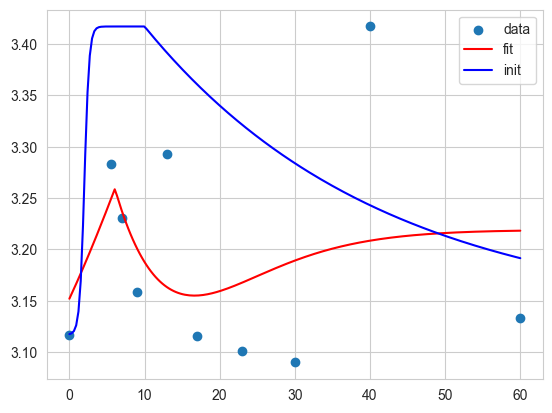

{'A': np.float64(2.9369208646609035), 'B': np.float64(0.800010350571913), 'c1': np.float64(9.999999998014708), 'w1': np.float64(0.999999999999879), 'C': np.float64(0.5182823379173661), 'c2': np.float64(6.060610979333428), 'w2': np.float64(-1.0646927983775714)}
Fitting row 43 (cMX1)


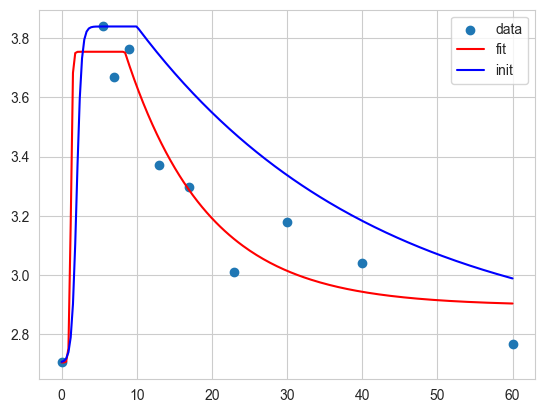

{'A': np.float64(2.7042896446765483), 'B': np.float64(1.0495055980877952), 'c1': np.float64(1.2290405937243425), 'w1': np.float64(-0.973612373467662), 'C': np.float64(0.8578081124384502), 'c2': np.float64(8.404888276058239), 'w2': np.float64(-1.036568329192581)}
Fitting row 44 (cOCUBM)


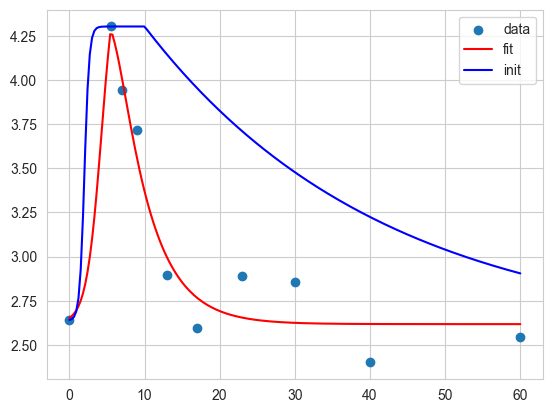

{'A': np.float64(2.6224864667926013), 'B': np.float64(2.1610813261268818), 'c1': np.float64(4.283621894100482), 'w1': np.float64(0.0021388242948819545), 'C': np.float64(2.1656679510054055), 'c2': np.float64(5.500000069221), 'w2': np.float64(-0.6327997047245976)}
Fitting row 45 (cSKBR3)


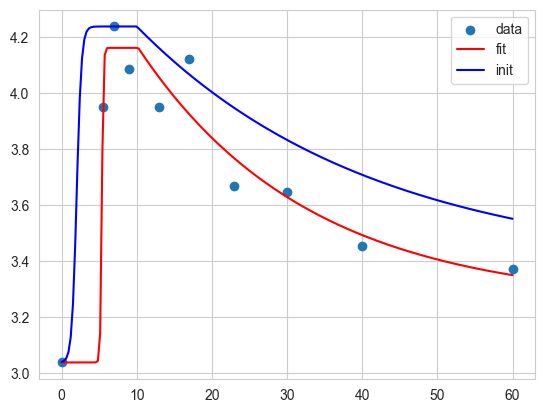

{'A': np.float64(3.0382968258571585), 'B': np.float64(1.1230702789137041), 'c1': np.float64(5.353799121660163), 'w1': np.float64(-0.9999628564143805), 'C': np.float64(0.9115681464609295), 'c2': np.float64(10.191098735075398), 'w2': np.float64(-1.3533511709639454)}
Fitting row 46 (cT47D)


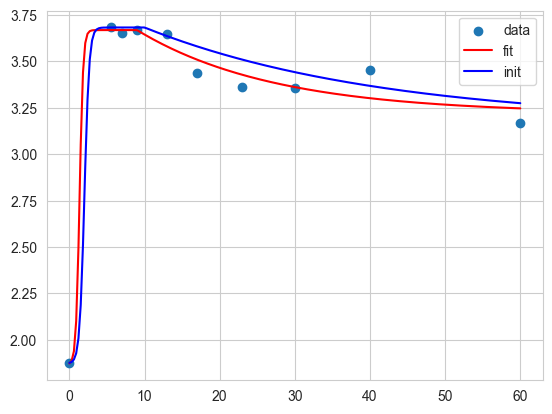

{'A': np.float64(1.8662945550197105), 'B': np.float64(1.8027038130811373), 'c1': np.float64(1.353159090912288), 'w1': np.float64(-0.6270440353113976), 'C': np.float64(0.44936842563387996), 'c2': np.float64(8.999999631282165), 'w2': np.float64(-1.2611599325323546)}
Fitting row 47 (cUACC3199)


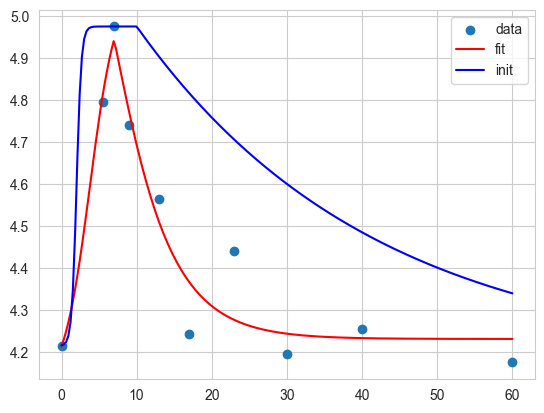

{'A': np.float64(4.110778130078529), 'B': np.float64(0.9692024384640591), 'c1': np.float64(3.786254691296388), 'w1': np.float64(0.24785032320214911), 'C': np.float64(0.8492620402289361), 'c2': np.float64(7.000000172002684), 'w2': np.float64(-0.7369474272933516)}
Fitting row 48 (cUACC812)


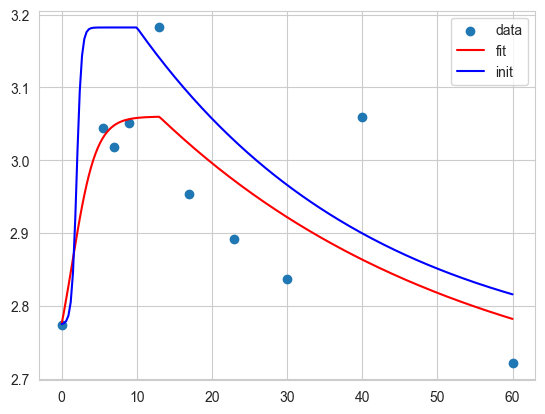

{'A': np.float64(2.6553532208074206), 'B': np.float64(0.4047192702196255), 'c1': np.float64(1.3897817948674773), 'w1': np.float64(0.20589041719888712), 'C': np.float64(0.40779360933604547), 'c2': np.float64(12.999999919466095), 'w2': np.float64(-1.6136534614243405)}
Fitting row 49 (cUACC893)


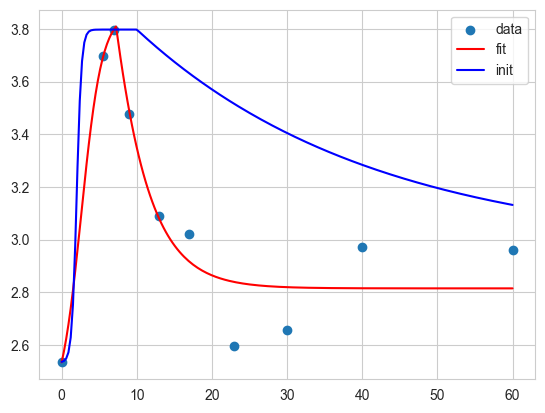

{'A': np.float64(2.333510360778615), 'B': np.float64(1.5282523931252936), 'c1': np.float64(2.61400345081906), 'w1': np.float64(0.14092700635680172), 'C': np.float64(1.0468265277182436), 'c2': np.float64(7.245690276424871), 'w2': np.float64(-0.6210997874697206)}
Fitting row 50 (cZR751)


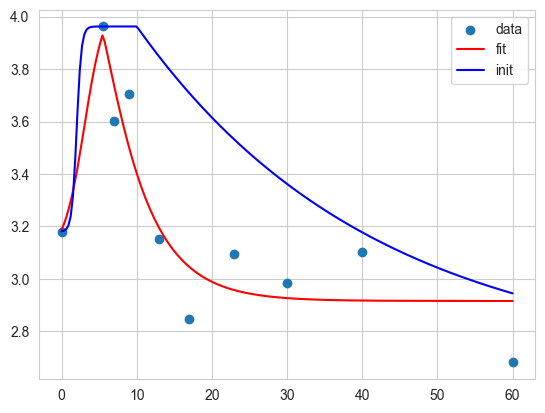

{'A': np.float64(3.088613503183928), 'B': np.float64(0.9868403045928481), 'c1': np.float64(3.025518867021401), 'w1': np.float64(0.139324111877132), 'C': np.float64(1.1597316526654589), 'c2': np.float64(5.499999970346671), 'w2': np.float64(-0.7199798574707035)}
Fitting row 51 (cZR7530)


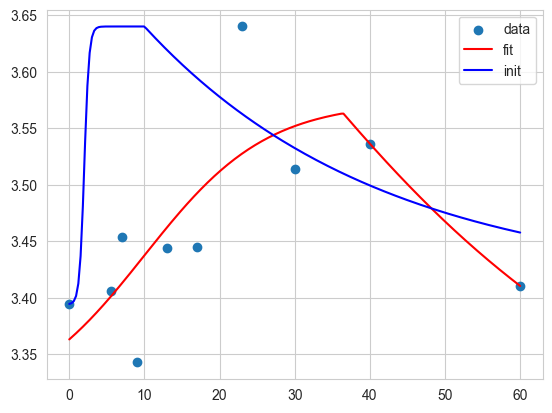

{'A': np.float64(3.3016043595235978), 'B': np.float64(0.2716523700690597), 'c1': np.float64(9.999999999999998), 'w1': np.float64(0.9110034703832843), 'C': np.float64(0.3883775591403896), 'c2': np.float64(36.45066126071643), 'w2': np.float64(-1.638966473713627)}


In [12]:
params_all = []
for iloc in range(len(df_ts)):
    print(f"Fitting row {iloc} ({df_ts.index[iloc]})")
    df_ts.iloc[iloc,:].values

    y = df_ts.iloc[iloc,:].values
    x = df_ts.columns.values.astype(float)
    x = x[~np.isnan(y)]
    y = y[~np.isnan(y)]
    res = fit_double_sigmoid(x, y, plot=True)
    params_all.append({'cell_line': df_ts.index[iloc], **res.params})
    print(res.params)

In [13]:
df_param = pd.DataFrame(params_all).set_index('cell_line')

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import basedir, evaluations_dir
from embedding_utils import perform_pca_on_embeddings

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

embedding_df = pd.read_csv(evaluations_dir / model / data/ "embeddings_figure1a.csv", index_col=0)
# Subset to multimodal with best_RFE_10_permute
embedding_df = embedding_df[~((embedding_df["context"] == "multimodal") &
                  (embedding_df["features"] == "RFE_10_permute"))]

# PCA across jobs
pca_embedding_df, _ = perform_pca_on_embeddings(embedding_df)

meta = pca_embedding_df[(pca_embedding_df.context=='multimodal') & (pca_embedding_df.samples=='BT20')]


Explained variance for cytof_init BT20: [0.88569986 0.07149924]; Total: 0.9572
Explained variance for cytof_init EVSAT: [0.82761275 0.13747782]; Total: 0.9651
Explained variance for cytof_init HCC1500: [0.78819232 0.19450485]; Total: 0.9827
Explained variance for cytof_init MCF7: [0.78815319 0.18051759]; Total: 0.9687
Explained variance for cytof_init UACC3199: [0.87379404 0.11852595]; Total: 0.9923
Explained variance for multimodal BT20: [0.71080104 0.26817064]; Total: 0.9790
Explained variance for multimodal EVSAT: [0.81647064 0.17208888]; Total: 0.9886
Explained variance for multimodal HCC1500: [0.81916947 0.13161908]; Total: 0.9508
Explained variance for multimodal MCF7: [0.65543575 0.31836512]; Total: 0.9738
Explained variance for multimodal UACC3199: [0.89117608 0.09129269]; Total: 0.9825
Explained variance for proteomics BT20: [0.49324765 0.37688372]; Total: 0.8701
Explained variance for proteomics EVSAT: [0.51286243 0.38400485]; Total: 0.8969
Explained variance for proteomics H

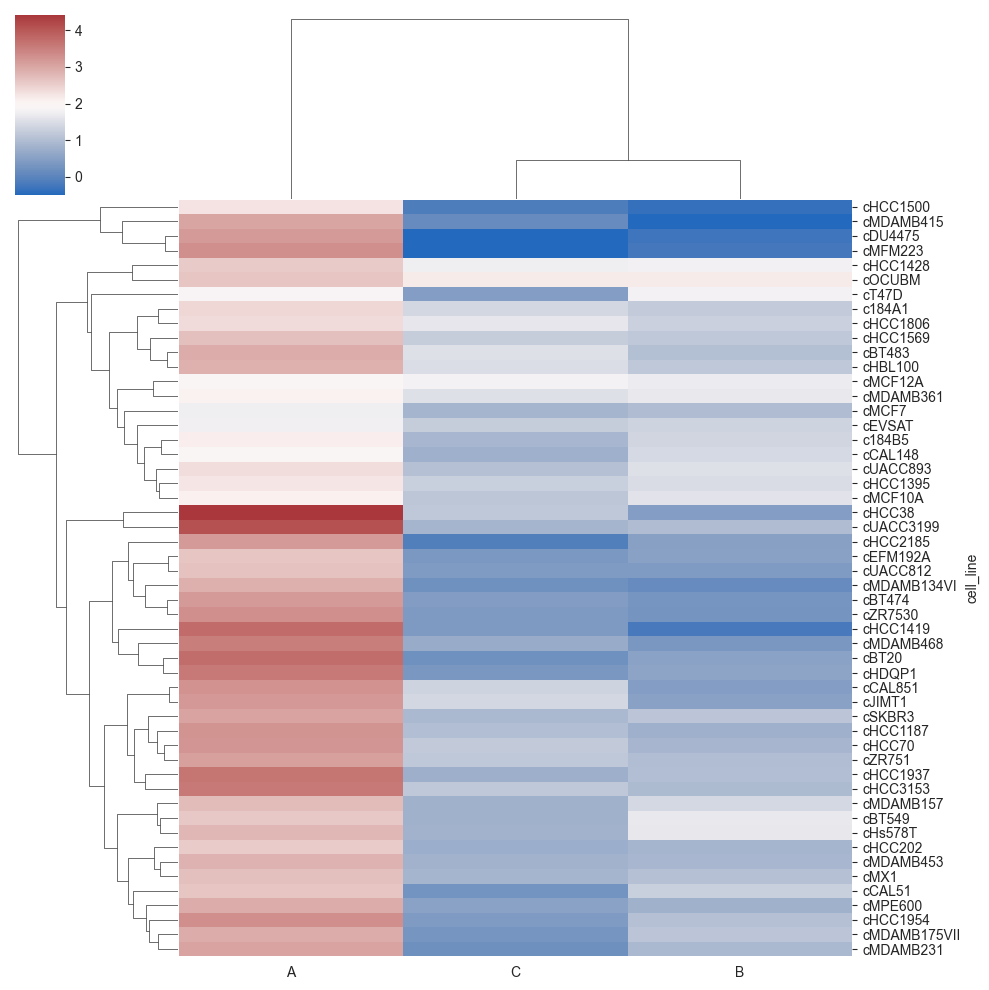

In [60]:
import seaborn as sns
sns.clustermap(df_param[['A','C','B']], yticklabels=True, cmap='vlag')

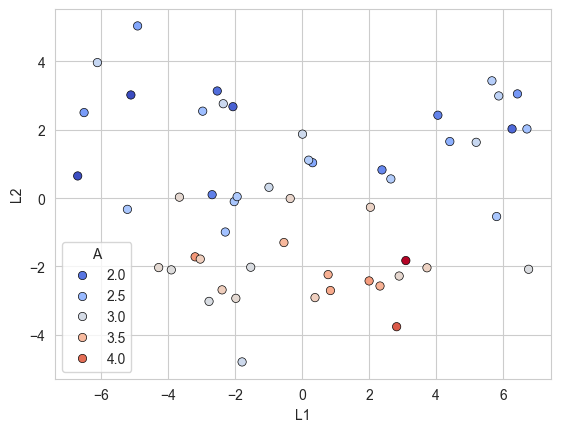

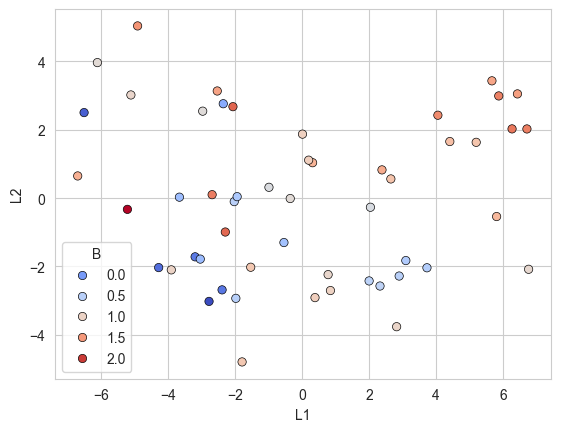

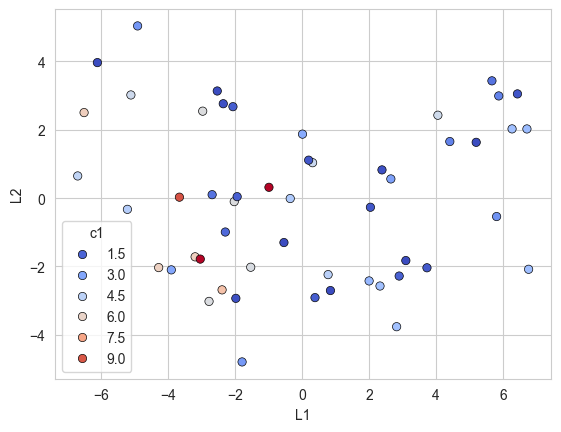

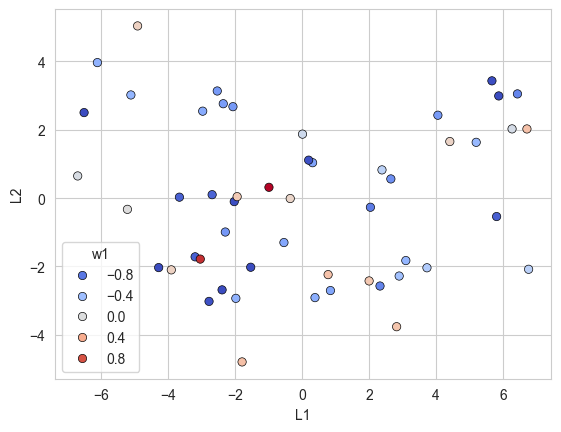

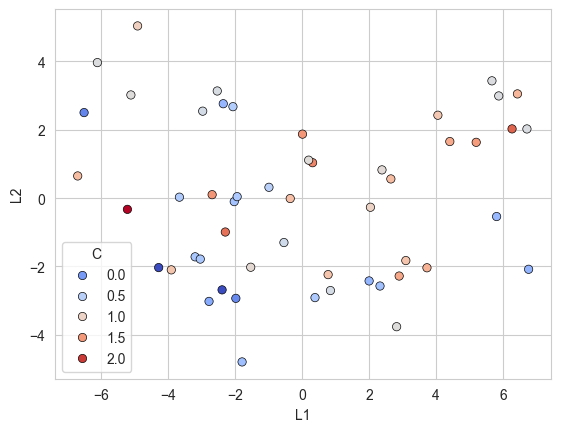

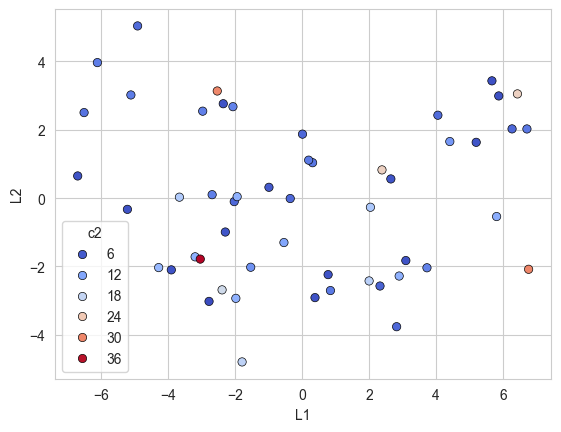

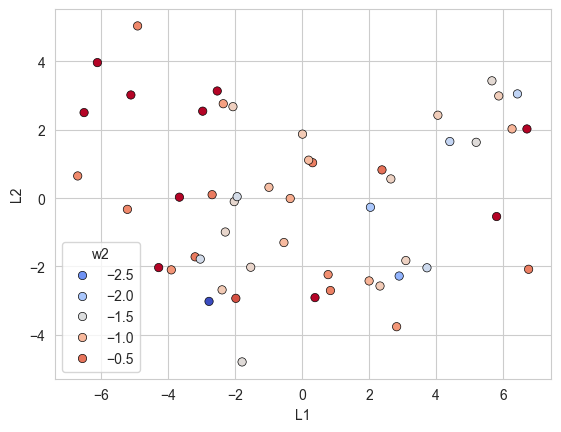

In [21]:
meta
for col in df_param.columns:
    meta[col] = df_param.loc[meta.index, col]
    sns.scatterplot(meta, x='L1', y='L2', hue=col,  palette="coolwarm" ,
        edgecolor="black",)
    plt.show()

In [17]:
df_param

,A,B,c1,w1,C,c2,w2
cell_line,,,,,,,
c184A1,2.410448,1.210343,2.137302,0.124668,1.383699,10.670196,-1.759444e+00
c184B5,2.126170,1.368212,1.138416,-0.226210,0.884221,23.000001,-4.818406e-01
cBT20,3.729785,0.536216,3.529082,0.220568,0.224934,17.000001,-9.591364e-01
cBT474,3.166303,0.292797,9.091126,-0.903108,0.433019,16.172328,-2.078265e-80
cBT483,2.923354,1.029317,3.110122,-0.111954,1.517378,7.000000,-1.190754e+00
cBT549,2.574730,1.657911,3.615150,0.271956,0.798861,8.244940,-4.512001e-32
cCAL148,1.948326,1.432695,1.000008,-0.621793,0.773379,29.843637,-1.644963e-15
cCAL51,2.625466,1.275235,2.535245,-0.913387,0.254327,12.727811,-1.381235e-12
cCAL851,3.258203,0.456801,1.304926,-0.296153,1.331853,9.000001,-1.682244e+00


<Axes: xlabel='A', ylabel='B'>

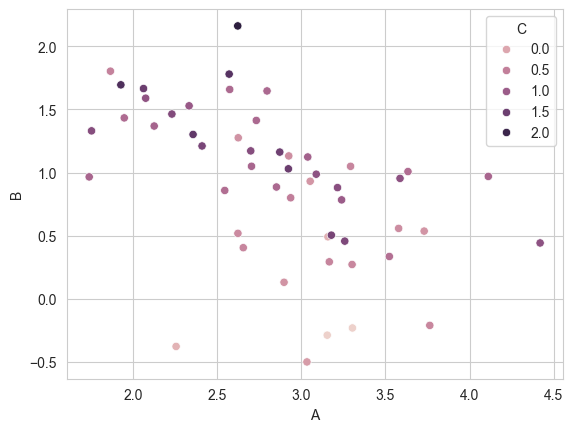

In [61]:
sns.scatterplot(df_param, x='A', y='B', hue='C')

<Axes: xlabel='C', ylabel='B'>

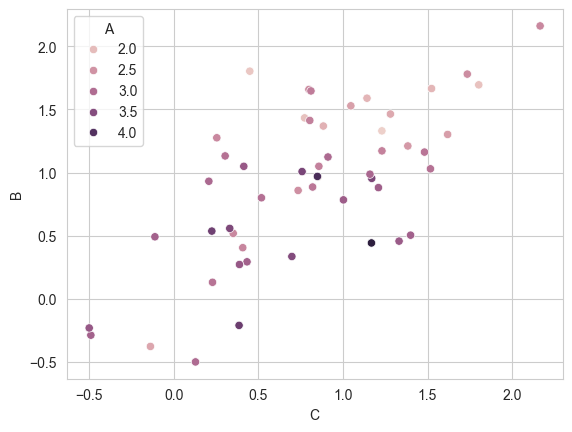

In [62]:
sns.scatterplot(df_param, x='C', y='B', hue='A')

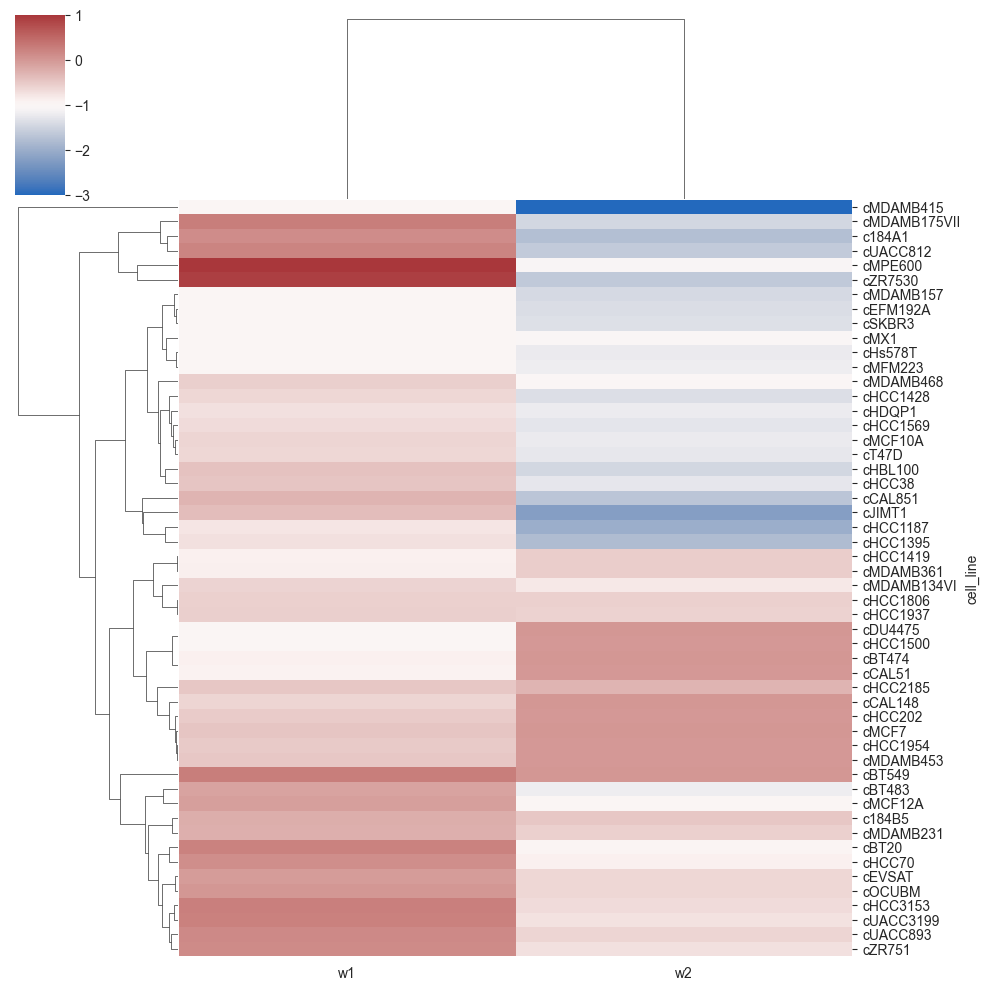

In [63]:
sns.clustermap(df_param[['w1', 'w2']], yticklabels=True, cmap='vlag')

<Axes: xlabel='w1', ylabel='w2'>

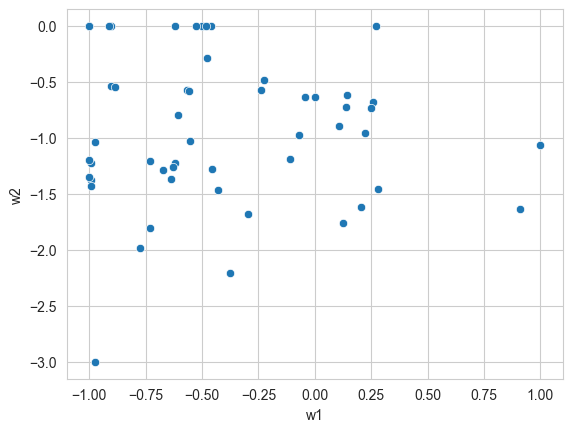

In [64]:
sns.scatterplot(df_param, x='w1', y='w2')

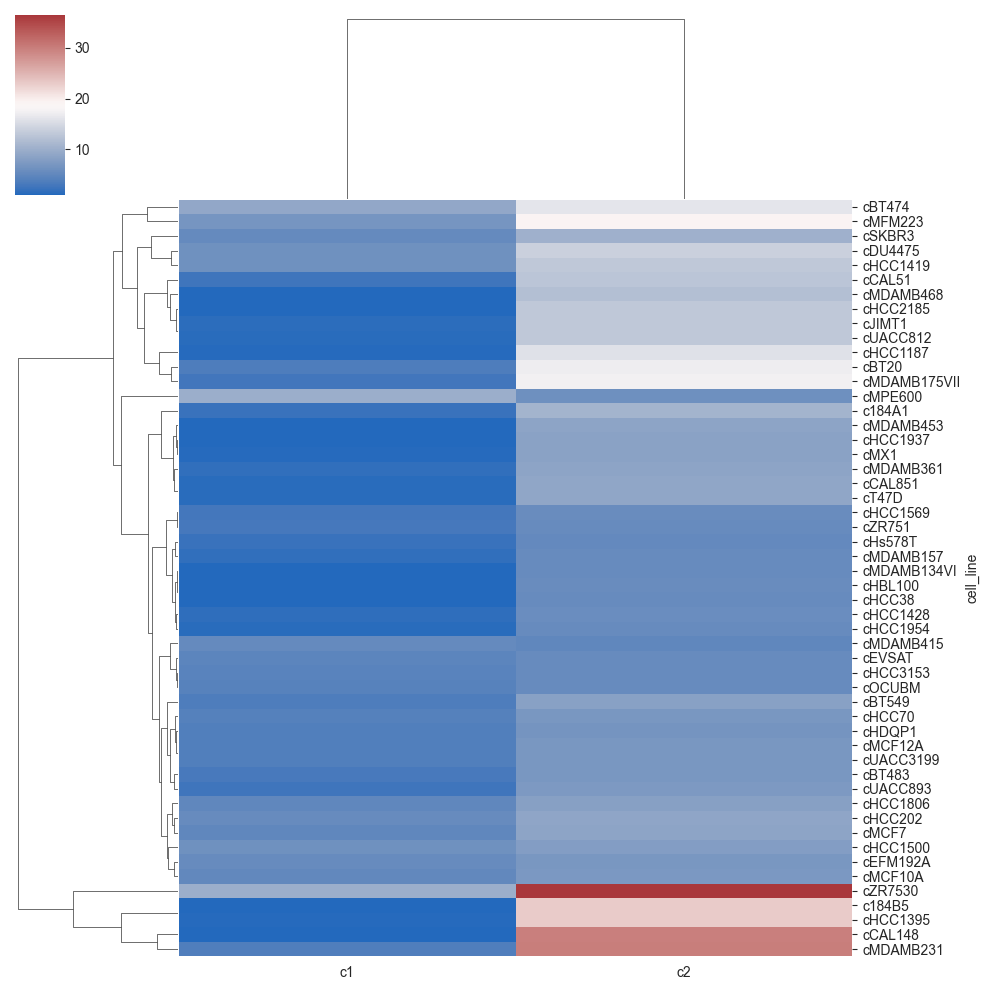

In [65]:
sns.clustermap(df_param[['c1', 'c2']], yticklabels=True, cmap='vlag')

<Axes: xlabel='c1', ylabel='c2'>

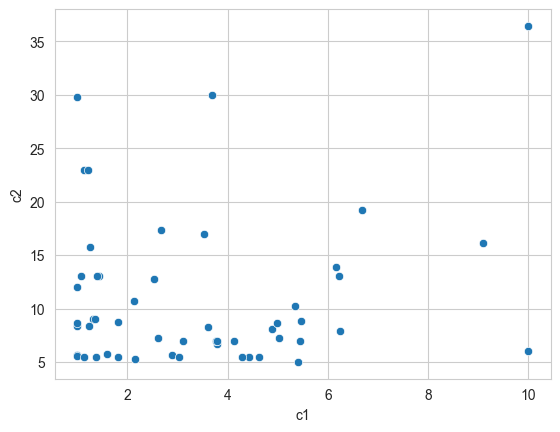

In [66]:
sns.scatterplot(df_param, x='c1', y='c2')

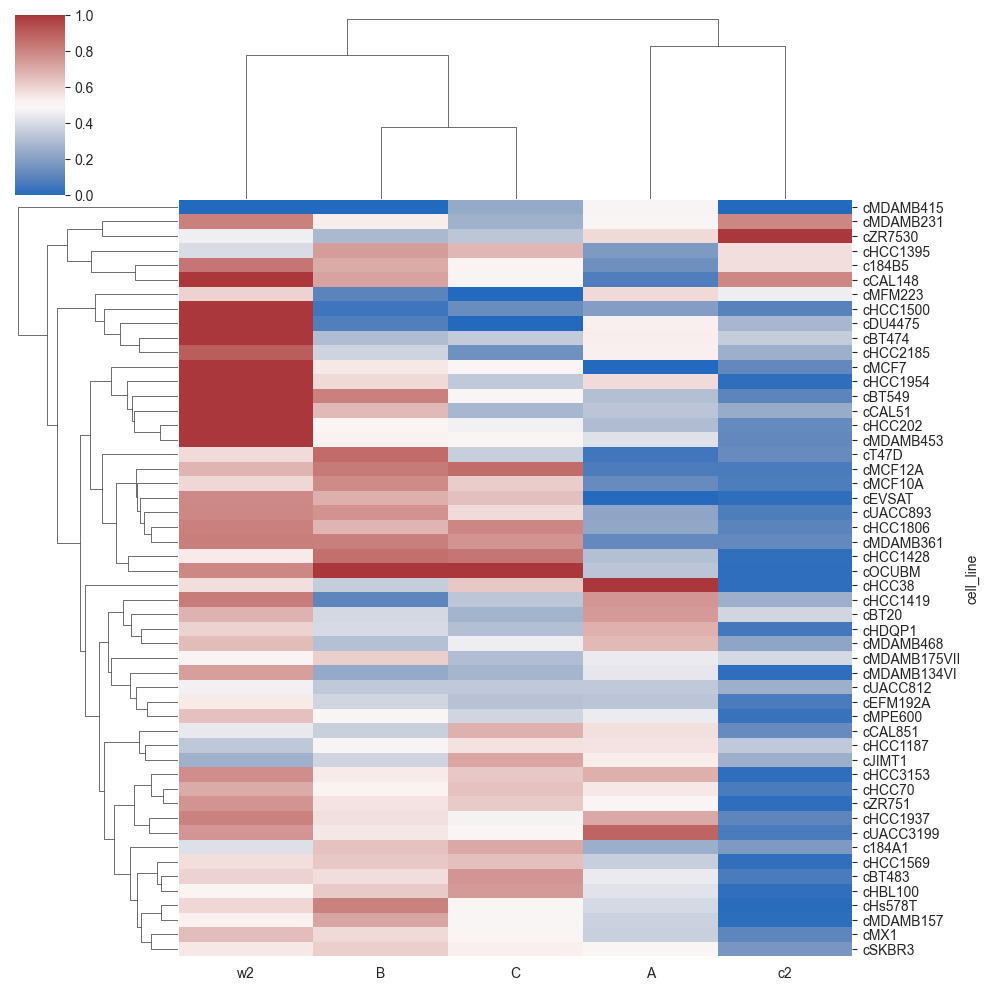

In [67]:
sns.clustermap(df_param[['A','B','C','w2', 'c2']], yticklabels=True, cmap='vlag', standard_scale=1)

In [68]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
embed = pca.fit_transform(df_param)

In [69]:
embed

array([[-0.31209448, -1.321718  ],
       [11.94809419, -2.9857327 ],
       [ 6.12463145, -0.11283955],
       [ 5.59296932,  5.42992164],
       [-3.92367883, -0.11667974],
       [-2.6369738 ,  0.34435964],
       [18.76938454, -3.52155947],
       [ 1.78597331, -0.95388569],
       [-2.01656299, -1.96831543],
       [ 3.19141181,  2.77315728],
       [-3.77686124,  2.28040585],
       [-5.33247216,  1.45108722],
       [-5.40535341, -2.15829766],
       [ 4.72347708, -2.45751484],
       [11.93231612, -3.01303623],
       [ 2.27721698,  2.82872491],
       [-5.31623893, -1.65548917],
       [-2.78584972,  3.17114704],
       [-5.26322936, -0.28881632],
       [-2.76298571,  1.53081932],
       [-2.65399564, -2.21425503],
       [-5.48862177, -1.65353453],
       [-1.90901348,  2.18753429],
       [ 2.00203779, -2.29823378],
       [-5.33347386,  1.34339042],
       [-5.46036096, -2.02727818],
       [-3.85424726,  0.95609702],
       [-4.2067547 ,  0.68580787],
       [-5.68695793,

In [95]:
rtks = ['EGFR', 'ERBB2', 'ERBB3', 'ERBB4', 'PGR', 'ESR1']
ligands = ['AREG', 'EREG', 'BTC', 'HBEGF', 'EPGN', 'NRG1', 'NRG2' ,'NRG3', 'NRG4']
emt = ['VIM', 'CDH1', 'CDH2', 'ACTA2', 'CTNNB1', 'DDR2']
rabs = [
    # https://doi.org/10.1111/febs.15453
    # E, endosome;
    # EE, early endosome;
    # ERC, endocytic recycling compartment
    # LE, late endosome
    # RE, recycling endosome
    # PM, plasma membrane
    'RAB1A', # EE/ER
    'RAB1B', # ER
    'RAB3B', # RE
    'RAB3C', # RE
    'RAB4A', # EE/RE
    'RAB4B', # EE/RE
    'RAB5A', # EE
    'RAB5B', # EE/PM
    'RAB5C', # EE
    'RAB7A', # LE
    # 'RAB7B', # LE, missing
    'RAB8A', # RE
    'RAB9A', # LE
    'RAB9B', # LE
    'RAB11A', # RE
    'RAB11B', # RE
    'RAB13', # RE
    'RAB14', # EE
    'RAB15', # EE/RE
    'RAB17', # RE
    'RAB21', # EE
    'RAB22A', # EE/RE
    'RAB25', # RE
    # 'RAB29', # RE, missing
    'RAB35', # EE
    'RAB36', # RE
]
cavs = ['CAV1', 'CAV2', 'CAV3']
markers = rtks + ligands + rabs + cavs + emt

df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx[df_tx['observableId'].isin(markers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px[df_px['observableId'].isin(markers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_p = df[df['simulationConditionId'].str.split('__').str[1]=='EGF'].pivot_table(
    index='preequilibrationConditionId', columns='FEATURE_ID', values='measurement'
)

for marker in markers:
    df_p[f't{marker}'] = df_tx.T[marker]
    if marker in df_px.index:
        df_p[f'p{marker}'] = df_px.T[marker]

In [97]:
df_p

FEATURE_ID,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,...,tVIM,pVIM,tCDH1,pCDH1,tCDH2,pCDH2,tACTA2,tCTNNB1,pCTNNB1,tDDR2
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,,
c184A1,1.947373,3.052297,5.107729,2.394946,1.212711,2.515484,1.933219,2.444833,3.471868,2.475011,...,1.041,-4.484608,7.094,-0.467109,-3.322,NaN,4.062,6.379,1.074033,-2.531
c184B5,1.957547,2.311961,5.958760,2.255738,0.884221,2.748893,2.553389,2.322446,3.593913,3.103394,...,-0.023,-6.755353,6.772,-0.441103,-3.322,NaN,4.074,6.634,1.139553,-3.283
cBT20,2.288187,2.228066,6.284131,2.814255,0.931947,2.182001,2.897757,2.525881,3.267079,4.466884,...,2.628,-7.532210,6.113,-0.652842,-3.322,-2.670579,-2.865,5.854,0.101261,-3.322
cBT474,1.828055,2.721244,6.125910,2.436720,0.998466,2.338102,2.587156,2.689460,2.548652,3.844061,...,5.073,-7.630686,7.589,-0.193469,0.731,NaN,-3.262,6.111,0.216243,-1.297
cBT483,2.003603,2.018609,7.331352,2.674595,1.038493,1.658971,2.338835,2.040013,2.703117,3.922285,...,-1.253,-2.750773,8.856,-0.568718,-0.054,NaN,-1.579,6.307,0.048287,-1.951
cBT549,3.562403,1.947643,8.340369,3.196664,0.709564,2.472409,2.759769,2.619844,3.421700,3.684110,...,9.954,1.048431,0.320,NaN,6.110,0.443139,7.381,6.404,-0.659172,5.341
cCAL148,2.744352,2.941269,6.918420,3.532479,1.095510,1.993400,3.637887,2.399182,2.564614,4.557559,...,1.720,-5.443132,6.141,-0.912983,-3.322,NaN,1.931,7.665,-0.040489,-1.073
cCAL51,4.260374,3.163223,7.745981,4.982450,1.130437,3.169486,3.208953,2.800299,3.244060,3.878464,...,6.903,-2.540656,3.034,-0.813976,5.958,0.733633,6.794,7.384,-0.909208,2.963
cCAL851,2.817698,2.424568,6.499465,3.707231,0.723475,2.334459,2.640060,2.198448,2.999721,3.610976,...,1.960,-6.843144,7.502,-0.243565,5.081,0.141848,2.292,6.321,1.045632,-3.322


In [98]:
import synapseclient
syn = synapseclient.Synapse()
syn.login()
file_id_table = pd.read_csv(
    syn.get("syn20631269").path, index_col=0
).set_index("fileID")
annotations = ['PAM50', 'Neve', 'Marcotte', 'Gene.cluster', 'Classification', 'primary.tumor', 'formed.mets', 'Growth.medium', 'Origin', 'AR', 'PGR', 'HER2', 'ERa', 'Lehmann', 'Ethnicity', 'cell_line']
df_annotation = file_id_table[annotations].groupby('cell_line').agg(
    lambda x: ' '.join(np.unique([str(x) for x in x]))
).reset_index()
df_annotation['cell_line'] = df_annotation['cell_line'].apply(lambda x: f'c{x}')
df_annotation = df_annotation.rename(columns={'cell_line': 'preequilibrationConditionId'}).set_index('preequilibrationConditionId')

for annotation in annotations:
    if annotation == 'cell_line':
        continue
    df_p[annotation] = df_annotation[annotation]

Welcome, Fabian Froehlich!

[syn20631269:FileID_table.csv]: Found existing file at /Users/frohlif/.synapseCache/298/42318298/FileID_table.csv, skipping download.


In [99]:
df_param

,A,B,c1,w1,C,c2,w2
cell_line,,,,,,,
c184A1,2.410448,1.210343,2.137302,0.124668,1.383699,10.670196,-1.759444e+00
c184B5,2.126170,1.368212,1.138416,-0.226210,0.884221,23.000001,-4.818406e-01
cBT20,3.729785,0.536216,3.529082,0.220568,0.224934,17.000001,-9.591364e-01
cBT474,3.166303,0.292797,9.091126,-0.903108,0.433019,16.172328,-2.078265e-80
cBT483,2.923354,1.029317,3.110122,-0.111954,1.517378,7.000000,-1.190754e+00
cBT549,2.574730,1.657911,3.615150,0.271956,0.798861,8.244940,-4.512001e-32
cCAL148,1.948326,1.432695,1.000008,-0.621793,0.773379,29.843637,-1.644963e-15
cCAL51,2.625466,1.275235,2.535245,-0.913387,0.254327,12.727811,-1.381235e-12
cCAL851,3.258203,0.456801,1.304926,-0.296153,1.331853,9.000001,-1.682244e+00


In [100]:
df_p['PC1'] = embed[:,0]
df_p['PC2'] = embed[:,1]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_10932/2312697489.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p['PC2'] = embed[:,1]



In [101]:
df_p

FEATURE_ID,CyclinB,GAPDH,IdU,Ki.67,b.CATENIN,cleavedCas,p.4EBP1,p.AKT.Thr308.,p.AMPK,p.Akt.Ser473.,...,Growth.medium,Origin,AR,PGR,HER2,ERa,Lehmann,Ethnicity,PC1,PC2
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,,
c184A1,1.947373,3.052297,5.107729,2.394946,1.212711,2.515484,1.933219,2.444833,3.471868,2.475011,...,MEBM+ transferrin and cholera toxin,normal mammary gland epithelium,negative,negative,negative,negative,BL2,0,-0.312094,-1.321718
c184B5,1.957547,2.311961,5.958760,2.255738,0.884221,2.748893,2.553389,2.322446,3.593913,3.103394,...,MEBM+1ngml cholera toxin,normal mammary gland epithelium,negative,negative,negative,negative,BL2,0,11.948094,-2.985733
cBT20,2.288187,2.228066,6.284131,2.814255,0.931947,2.182001,2.897757,2.525881,3.267079,4.466884,...,EMEM +10% FBS,carcinoma,negative,negative,negative,negative,LAR,W,6.124631,-0.112840
cBT474,1.828055,2.721244,6.125910,2.436720,0.998466,2.338102,2.587156,2.689460,2.548652,3.844061,...,RPMI-1640 +10% FBS,ductal carcinoma,positive,positive,positive,positive,0,W,5.592969,5.429922
cBT483,2.003603,2.018609,7.331352,2.674595,1.038493,1.658971,2.338835,2.040013,2.703117,3.922285,...,RPMI-1640 +10 insulin+20% FBS,ductal carcinoma,negative,positive,negative,positive,0,W,-3.923679,-0.116680
cBT549,3.562403,1.947643,8.340369,3.196664,0.709564,2.472409,2.759769,2.619844,3.421700,3.684110,...,RPMI-1640+0.023 insulin +10% FBS,ductal carcinoma,positive,negative,negative,negative,M,W,-2.636974,0.344360
cCAL148,2.744352,2.941269,6.918420,3.532479,1.095510,1.993400,3.637887,2.399182,2.564614,4.557559,...,DMEM + 10% FBS,adenocarcinoma,positive,negative,negative,negative,LAR,0,18.769385,-3.521559
cCAL51,4.260374,3.163223,7.745981,4.982450,1.130437,3.169486,3.208953,2.800299,3.244060,3.878464,...,DMEM + 10% FBS,adenocarcinoma,negative,negative,negative,negative,M,0,1.785973,-0.953886
cCAL851,2.817698,2.424568,6.499465,3.707231,0.723475,2.334459,2.640060,2.198448,2.999721,3.610976,...,DMEM + 10% FBS,adenocarcinoma,negative,negative,negative,negative,IM,0,-2.016563,-1.968315


<Axes: xlabel='PC1', ylabel='PC2'>

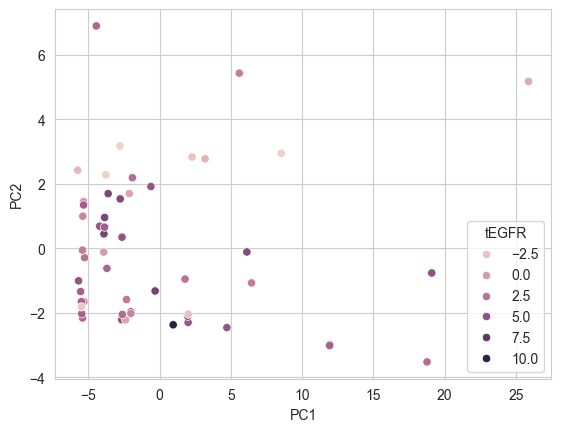

In [102]:
sns.scatterplot(df_p, x='PC1', y='PC2', hue='tEGFR')

<Axes: >

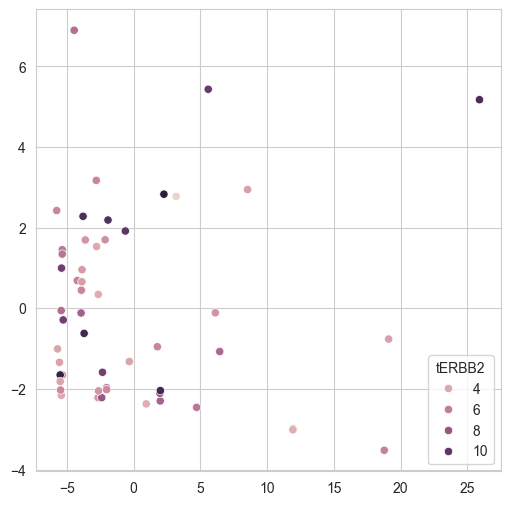

In [103]:
import seaborn as sns
plt.figure(figsize=(6,6))
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df_p['tERBB2'])

In [104]:
for par in ['A','B','C','c1','c2','w1','w2']:
    df_p[par] = df_param[par]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_10932/1085320566.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p[par] = df_param[par]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_10932/1085320566.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p[par] = df_param[par]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_10932/1085320566.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

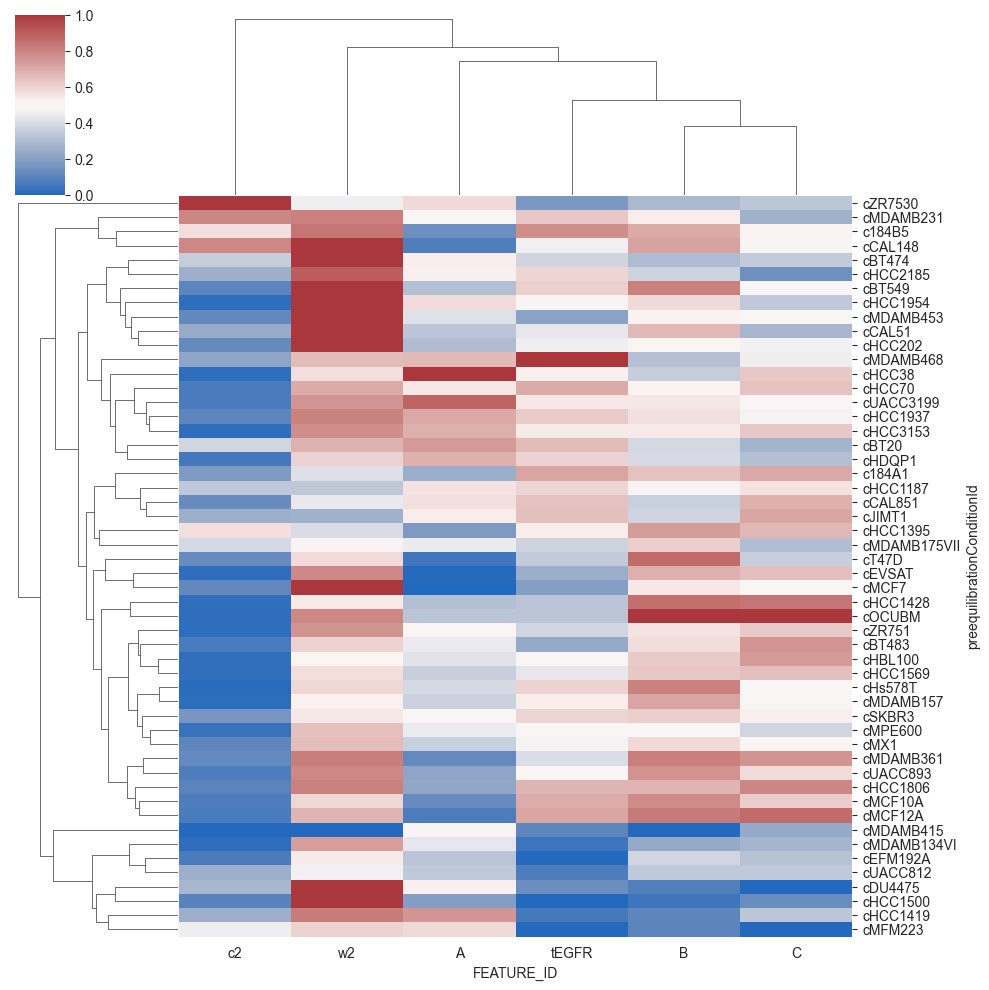

In [105]:
sns.clustermap(df_p[['A','B','C','w2', 'c2', 'tEGFR']], yticklabels=True, cmap='vlag', standard_scale=1)

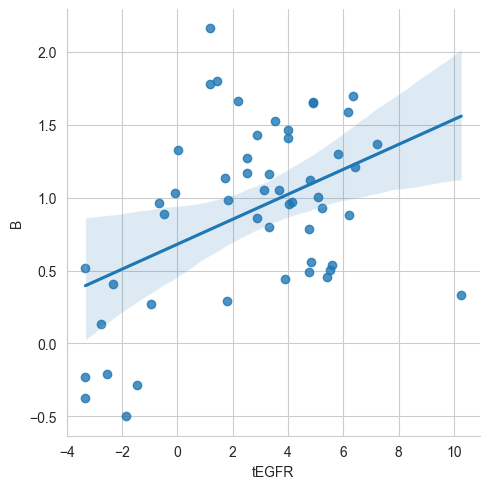

In [106]:
sns.lmplot(df_p, y='B', x='tEGFR')

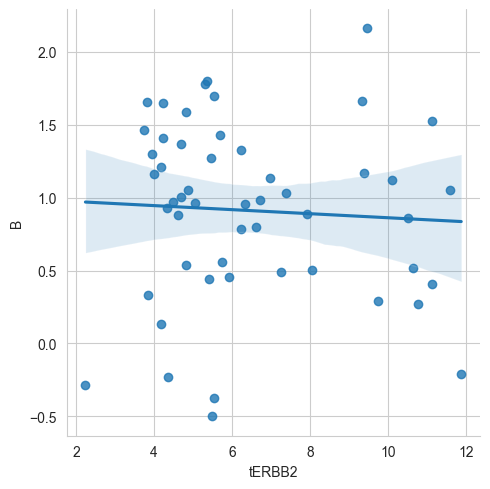

In [107]:
sns.lmplot(df_p, y='B', x='tERBB2')

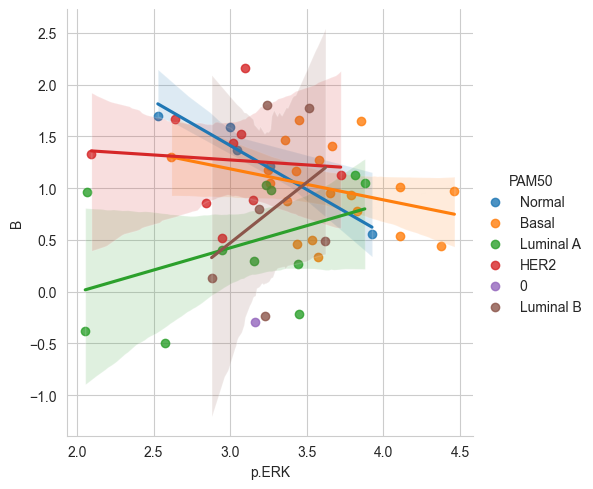

In [108]:
sns.lmplot(df_p, y='B', x='p.ERK', hue='PAM50')

<Axes: xlabel='PAM50', ylabel='B'>

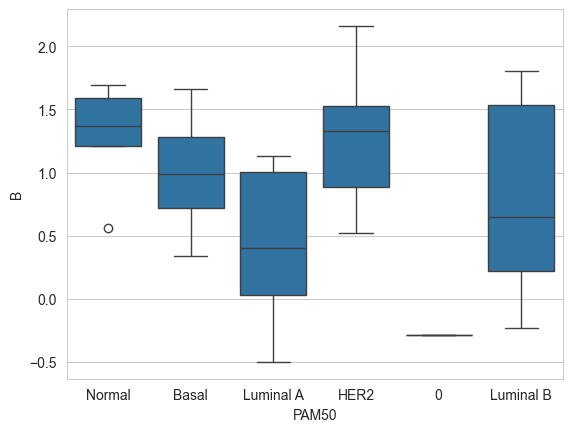

In [109]:
sns.boxplot(df_p, y='B', x='PAM50')

<Axes: xlabel='Neve', ylabel='B'>

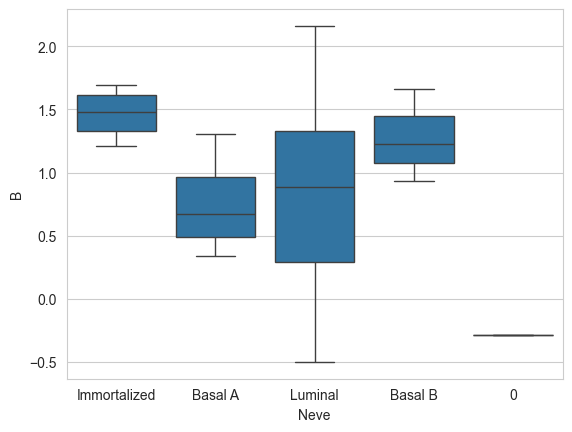

In [110]:
sns.boxplot(df_p, y='B', x='Neve')

<Axes: xlabel='Neve', ylabel='A'>

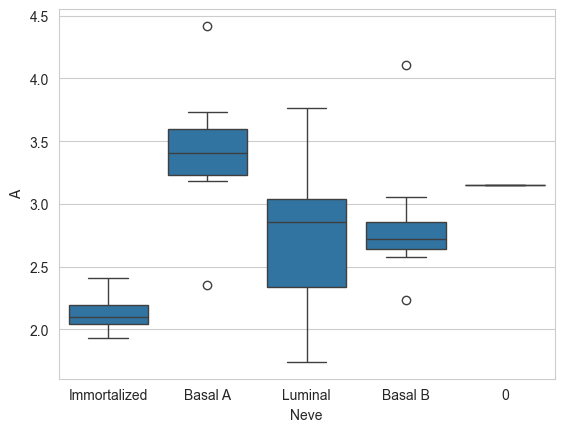

In [111]:
sns.boxplot(df_p, y='A', x='Neve')

<Axes: xlabel='PAM50', ylabel='A'>

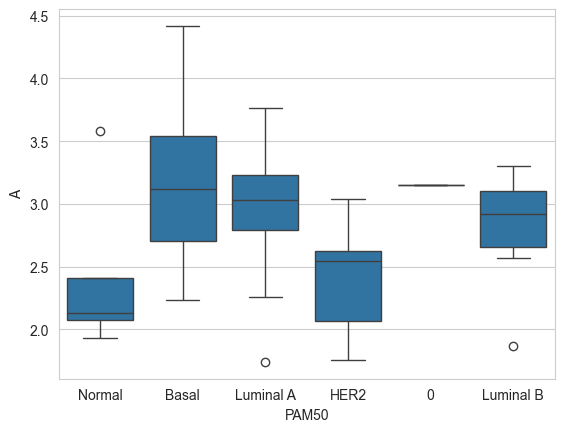

In [112]:
sns.boxplot(df_p, y='A', x='PAM50')

<Axes: xlabel='PAM50', ylabel='C'>

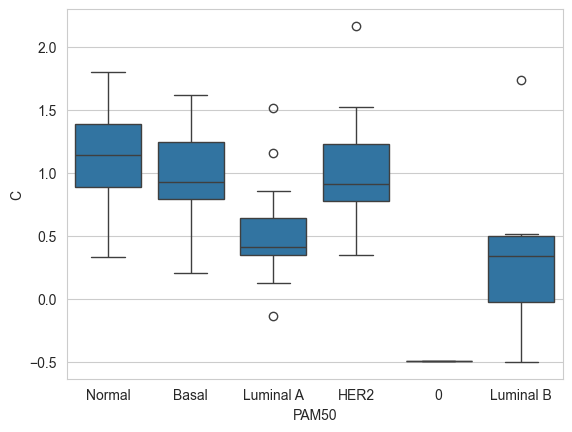

In [113]:
sns.boxplot(df_p, y='C', x='PAM50')

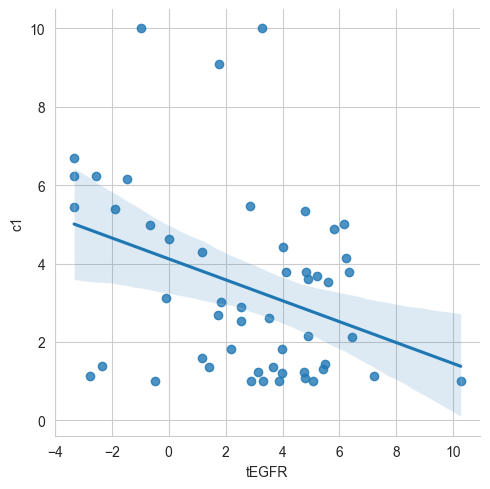

In [114]:
sns.lmplot(df_p, y='c1', x='tEGFR')

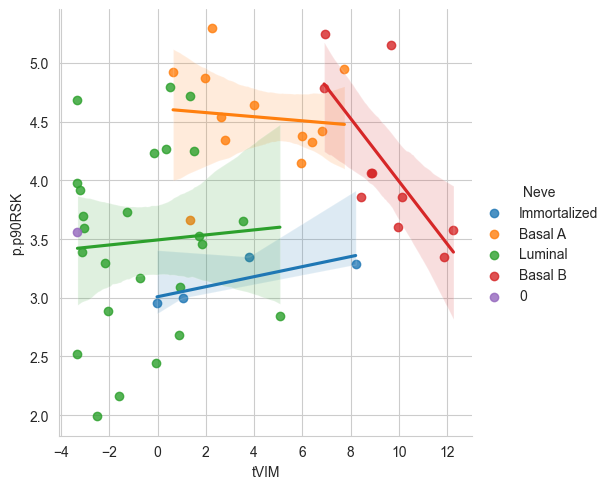

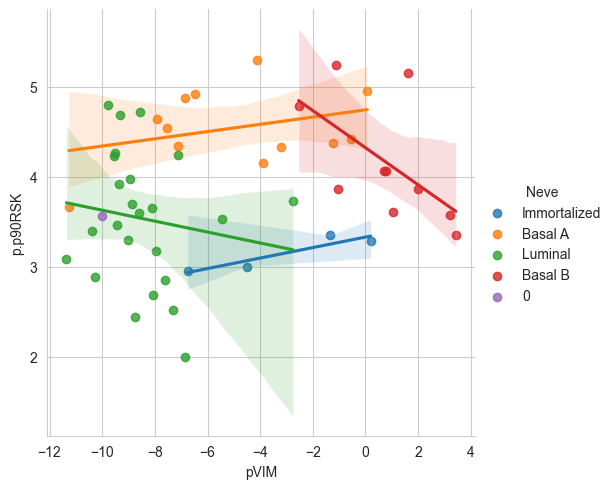

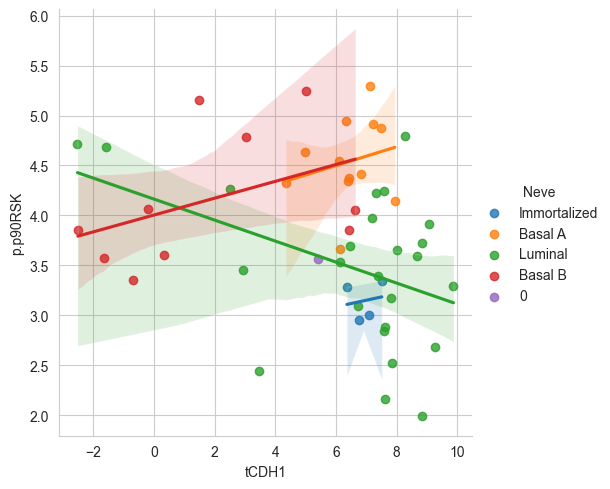

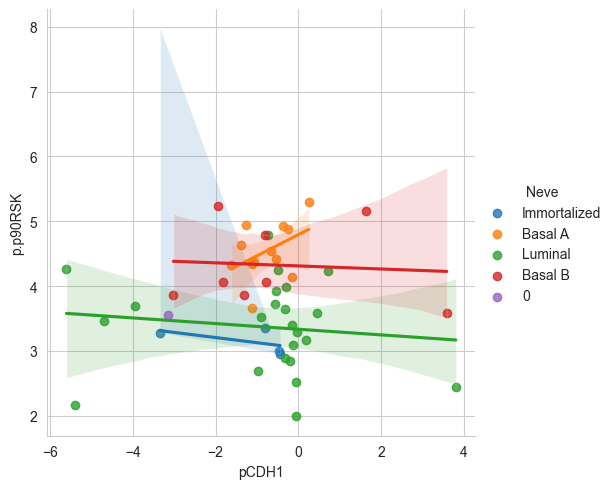

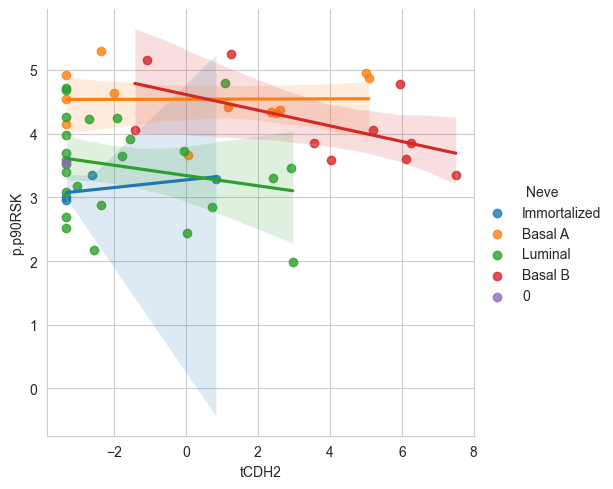

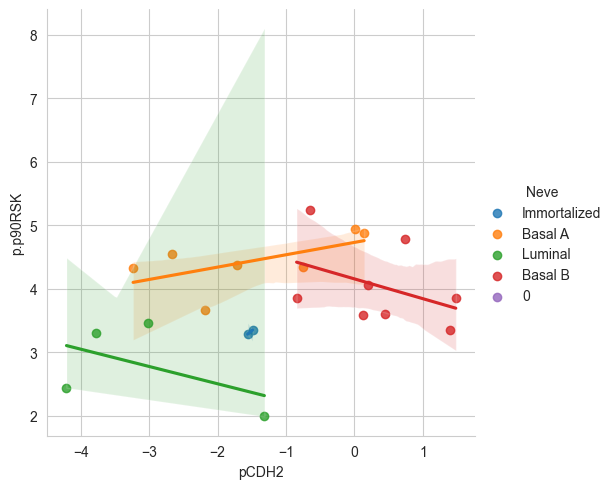

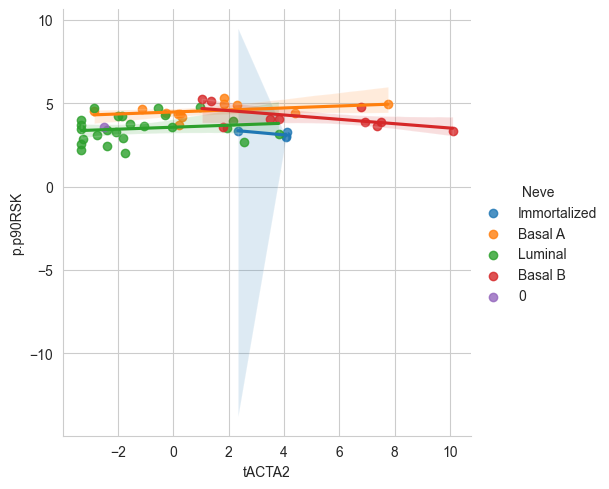

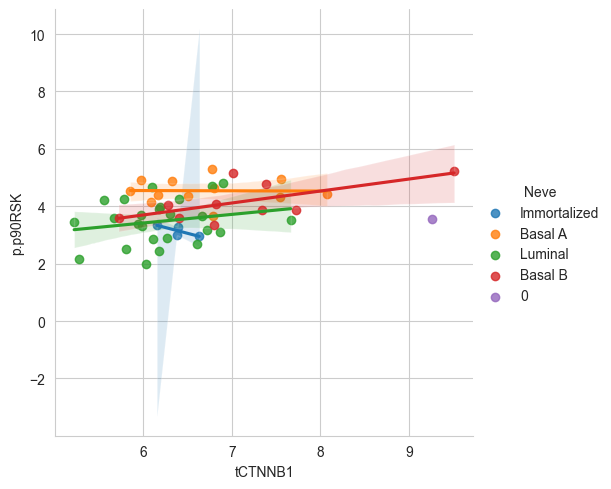

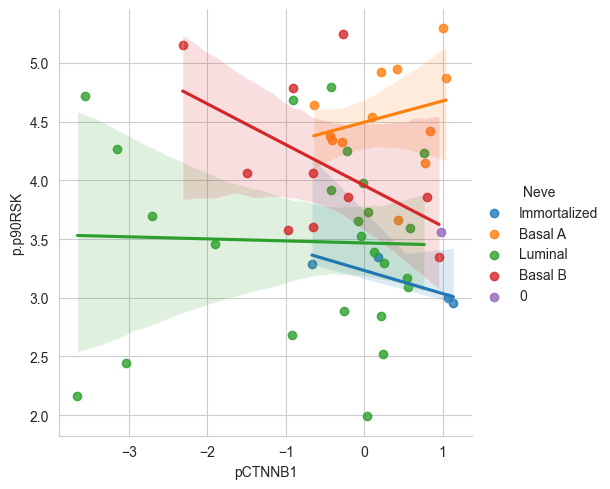

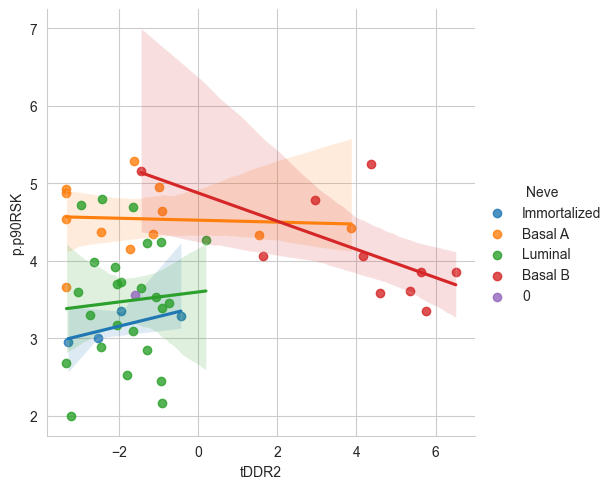

In [115]:
for m in emt:
    sns.lmplot(df_p, y='p.p90RSK', x=f't{m}', hue='Neve')
    if f'p{m}' in df_p.columns:
        sns.lmplot(df_p, y='p.p90RSK', x=f'p{m}', hue='Neve')